# <center>编译式 RAG：LLM Wiki 原理详解（Karpathy 范式 + GBrain 生产实现）</center>

&emsp;&emsp;今天我们聚焦的是一种正在被重新讨论的知识管理范式——`编译式 RAG`，也就是 Andrej Karpathy 在「LLM Wiki」这篇 gist 里提出的那套思路。如果你用过向量库、写过检索增强生成的应用，大概率清楚传统 RAG 是怎么干活的：先把资料切成 chunk、算好 embedding、写进一份向量索引，查询时再临时召回相关片段、交给大模型当场归纳。编译式 RAG 想换的不是"有没有中间产物"——两条路线都有中间产物——而是"中间产物到底是什么"：它先把原始资料一次性"编译"成一份结构化、互相链接、人类可读的 wiki，之后的查询直接读这份已经提炼好的产物，而不是每次都从索引里捞片段重新归纳。

&emsp;&emsp;这堂课我们会重点抓住三件事。第一，把"编译执行 vs 解释执行"这个核心隐喻讲透，并且当场把它跑成你能亲眼看见的物证——`raw/` 一字未动、`wiki/` 从空目录长出一批互链页。第二，看一个相当反直觉的能力：`GBrain` 这个生产级实现，能在完全不调用任何大模型的前提下，把 markdown 里写好的链接自动接成一张带类型的知识图谱。第三，也是最重要的一件事——我们会用一手实测数据给这个范式做一次诚实的体检：它的查询成本不是更省，而是高出约一个数量级（约 20 倍）。它有明确的适用边界，不是对传统 RAG 的全面替代。学会判断"我的场景到底该不该用它"，和学会怎么搭它同样重要。

&emsp;&emsp;为了把这些讲清楚，接下来我们会按一条完整的管线展开：先看清传统 RAG 与编译式 RAG 的真正分野——一个以机器索引为中间产物、一个以可读 wiki 为中间产物（第一章），再拆解编译式范式的原理骨架（第二章），然后亲手跑通一个最小编译闭环（第三章），看 GBrain 零大模型自动建图（第四章），用诚实的数据做三元选型（第五章），最后把这套方法迁移到你自己的笔记上（第六章）。

> 📌 **目标受众与前置要求**：本课面向有 RAG 使用经验（用过或听说过向量库）的职场技术人——对编译式范式你可能是第一次接触，这没关系。技术上你需要会用终端、能跟着敲命令、Python 达到中级（能看懂代码、不需要教基础语法），并且会用一个 LLM agent（如 `Claude Code`）。**不需要**你提前装好任何重型工程环境，也不需要 GPU。

> 📌 **学完本节你将带走 5 件产物**：① 在自己机器上独立搭起一个 LLM Wiki 最小编译闭环，把一批笔记 ingest 成互链 wiki；② 在 Obsidian Graph View 里看到知识图谱"长出来"，并能指着某条连线说出它对应哪两页；③ 用 `gbrain backlinks` 把某条边精确追溯到它来自哪一行 markdown；④ 一份跑通的"解释执行 vs 编译执行"四维对照实验，并亲眼确认两种范式都要在源材料变化后更新自己的中间产物；⑤ 一套能用一句话判断"我的场景该用编译式还是传统 RAG"的选型决策树。

> **【学完不能做·诚实划界】**：本节不覆盖 `GBrain` 的 Storage / Retrieval 全栈细节（我们只深用它的自动建图能力）；不展开端到端的混合检索四场景实战；不展开 Obsidian 的插件、Dataview、主题美化（我们只用它"打开文件夹看网络"这一步）。这些是更深的内容，今天先把范式的本质和边界吃透。

> 📅 **时效性说明**：本课的实操命令与截图全部来自 2026 年 6 月初的真实实验。编译器 agent 使用 `Claude Code v2.1.170`（Opus 4.8、订阅鉴权）；生产实现 `GBrain` 锁定版本 `0.42.44.0`。`GBrain` 是活跃迭代项目，小版本之间可能有破坏性变更——你跟跑时如遇命令行为差异，以你本机版本的 `--help` 为准。Karpathy LLM Wiki 概念源头见 <https://gist.github.com/karpathy/442a6bf555914893e9891c11519de94f>，GBrain 仓库见 <https://github.com/garrytan/gbrain>。

---

## <center>第一章：从机器索引到可读 wiki：两种 RAG 范式的真正分野</center>

&emsp;&emsp;这一章我们不从"谁更先进"讲起，而是先把两种 RAG 范式的**中间产物**看清楚。传统向量 RAG 会把原始资料切成 chunk、算 embedding、写进向量索引，查询时再临时召回片段、交给大模型综合；编译式 RAG 则先把原始资料 ingest / compile 成一份人类可读的 wiki，查询时优先读这份产物。这一章不写实战代码（最后一节有一段可选的复现实验），只做一件事：帮你建立一个准确的比较框架——看清这两条路线的中间产物到底差在哪、又在哪一点上其实一样。

### 1.1 传统 RAG：把资料组织成机器索引

&emsp;&emsp;先把传统向量 RAG 的工作方式弄清楚。它的第一步是**离线建一份中间产物**：把原始文档切成一个个 chunk，给每个 chunk 算出一串向量（`embedding`），连同元数据一起写进一个**向量索引**。这一步做完，原始资料就被组织成了一份机器能快速检索的结构。查询来的时候，系统把你的问题也向量化，去索引里召回**最相关的 top-k 个片段**，再把这几个片段拼进 prompt、交给大模型当场归纳出答案。

<div align=center>
  <img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260227114146495.png" width=60%>
</div>

&emsp;&emsp;请记住它的中间产物长什么样：**chunks ＋ embeddings ＋ 向量索引 ＋ 元数据**——这是一份**给机器读**、高度优化过的检索结构。这套方案绝不是"落后"：它在**海量文档**（十万、百万级）、**高频更新**、**单跳事实检索**这些场景里非常成熟，召回宽、响应快（毫秒级），还能用增量索引、重排（`rerank`）、缓存、混合检索一路继续优化，工程生态也最完整。

&emsp;&emsp;它的代价同样清楚，而且不该被说成"缺陷"——它们是这套工程取舍的另一面：跨源的综合与对齐多在**查询期临时做**；召回、排序、生成层层叠加会带来结果波动；向量索引是给机器读的，**人类很难直接打开审查**；源文档变了之后，需要**重建或增量更新索引**，索引才能跟上。一句话——

> **传统 RAG 不是"落后方案"，它是把知识组织成机器索引、再在查询期临时取片段临时综合答案的方案。它强在规模、速度和工程成熟度，弱在跨源合成的可读沉淀。**

### 1.2 编译式 RAG：把资料组织成可读 wiki

&emsp;&emsp;换编译式 RAG 来处理同一批资料，它的中间产物完全不同。它的第一步不是算向量、建索引，而是让一个大模型把原始资料**一次性 ingest / compile 成一份 wiki**：一组互相用 `[[链接]]` 连接的 markdown 页面，外加一个导航入口 `index.md` 和一份变更日志 `log.md`。原始资料（`raw/`）是事实源头，编译出来的 wiki（`wiki/`）才是它持续拥有并维护的产物。查询来的时候，它默认只读 wiki：先看 `index.md` 导航定位，再读那几个已经把要点提炼好、把矛盾对齐好的产物页，给出带 `[[链接]]` 引用的回答——**不再回去重读 `raw/` 原料**。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171508041.png" width=50%></div>

&emsp;&emsp;这里你只需要先抓住一个直观感受：**编译式查询读的是"已经想明白的产物"，不是"原始的一堆资料"**。它的中间产物是 markdown，所以**人类可以直接打开阅读**，可以 `diff`、可以审计、可以记进 `log`；它特别适合**稳定知识的跨源合成**——把多篇资料里互相矛盾的说法在编译期对齐好、把引用和结论提前整理好，之后每次查询直接复用这份结构。

&emsp;&emsp;但必须提前说清它的代价，免得把它当成魔法：编译（`ingest`）本身有成本；`raw/` 改了之后，**需要重新 ingest / compile，wiki 才会更新**（它不会自动读到磁盘上的变化）；查询 token 不一定低、甚至可能更高（第五章会用约 20 倍的实测展开）；编译还可能丢事实、把错误固化进产物。核心一句——

> **编译式 RAG 不是让知识自动同步，而是把知识先整理成一份可读、可维护、可审计的 wiki。它解决的不是"更新按钮消失了"，而是"中间产物从黑箱索引变成了可治理的知识资产"。**

### 1.3 共同边界：源材料变了，中间产物都要更新

&emsp;&emsp;把 1.1 和 1.2 并排放，你会发现一个很多人忽略的共同点——这也是这门课最想先帮你校正的一个直觉。两种范式都依赖一份"物化"出来的中间产物，于是它们都逃不掉同一个工程事实：**源材料变了，中间产物如果不更新，系统就会用旧内容回答**。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171528827.png" width=58%></div>

&emsp;&emsp;具体到两条路线：传统 RAG 改了源文档、不重建向量索引，查询命中的还是旧片段，答旧值；编译式 RAG 改了 `raw/`、不重新 ingest，查询读的还是旧 wiki 页，同样答旧值。所以——

> **"文档更新后答旧值"不是传统 RAG 独有的毛病，而是所有依赖中间产物的知识系统都会遇到的问题。区别不在"谁能自动同步"（两者都不能），而在"中间产物是机器索引，还是可读、可 diff、可审计的 wiki"。**

&emsp;&emsp;这很像数据库里的**物化视图**（materialized view）：源表变了、视图不刷新，查询拿到的就是旧视图。传统 RAG 的索引是物化出来的**机器视图**，编译式 RAG 的 wiki 是物化出来的**可读知识视图**——两者都得"刷新"，只是刷新出来的产物一个给机器看、一个给人看。第三章 3.10 节，我们会把这件事在两种范式上**各跑一遍**给你亲眼看。

> **【常见误区】**：很多人以为"编译式 RAG 把知识沉淀下来了，更新自然就会跟上"。实际上编译式同样不会自动同步——`raw/` 改了不重新 ingest，wiki 还是旧产物。后果是你以为它"活的"、其实它停在上一次编译的快照上；正确做法是把"重新编译"当成一道明确的运维动作（就像传统 RAG 要"重建索引"一样）；判断自己是否踩坑的方法——改一个 `raw/` 里的醒目数字、不重新 ingest 直接查，看它答新值还是旧值。

### 1.4 真正差异：索引黑箱 vs wiki 可治理

&emsp;&emsp;既然"要不要更新中间产物"两者一样，那真正把它们分开的是什么？是**中间产物的性质**。下面这张表把两种范式的中间产物逐维度摆开——读的时候请重点盯"人类可读性"和"审计方式"这两行，那才是分野所在。

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>两种 RAG 范式的中间产物对照</font></p>

<div class="center">

| 维度 | 传统向量 RAG | 编译式 RAG |
|------|------------|-----------|
| 中间产物 | chunks / embeddings / 向量索引 | markdown wiki / index.md / log.md |
| 人类可读性 | 弱（给机器检索用） | 强（可直接打开阅读） |
| 查询方式 | 查询期召回 top-k 片段 | 查询期读 wiki 页 |
| 跨源合成 | 多在查询期临时做 | 可在编译期提前沉淀 |
| 更新机制 | 源变更后重建 / 增量更新索引 | 源变更后重新 ingest / compile wiki |
| 审计方式 | 查 chunk、元数据、索引状态 | 读 wiki、看 diff、查 log |
| 适合场景 | 海量、高频、单跳事实 | 稳定、规模可控、跨源合成 |

</div>

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171605260.png" width=58%></div>

> **编译式 RAG 的价值不是"比传统 RAG 更自动"，而是"把机器索引换成可读 wiki，让知识的组织过程可见、可改、可追踪"。**

### 1.5 先给选型直觉：什么时候用传统 RAG，什么时候用编译式

&emsp;&emsp;第一章不急着教你怎么搭，先帮你建立一个正确的比较框架——免得后面学得越深，越容易把编译式当成"全面更优"。下面这张表给一个先行的选型直觉（第五章会用实测数据把它收成一棵完整的决策树）。

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>四种知识方案的先行选型直觉</font></p>

<div class="center">

| 场景 | 更适合 |
|------|--------|
| 海量文档、频繁更新、单跳事实查询 | 传统向量 RAG |
| 知识稳定、资料规模可控、需要跨源合成 | 编译式 RAG |
| 纯散文里抽实体关系、做多跳关系推理 | GraphRAG |
| 核心知识稳定 ＋ 外围数据海量易变 | 混合方案 |

</div>

&emsp;&emsp;收束成一句先行判断：**编译式 RAG 不是传统 RAG 的全面替代**。它更像是在"知识稳定、规模可控、需要跨源合成"这一类场景里，把机器索引换成一份可治理的 wiki。带着这个框架，我们先动手把"不更新中间产物就会答旧值"这件事，在传统 RAG 上亲眼跑一遍——它既是本课第一段代码，也是第三章 3.10 节的参照系。

### 1.6 可选实验：不更新中间产物，就会答旧值

&emsp;&emsp;1.3 我们说"源材料变了、中间产物不更新就会答旧值"，这一节把这句话从"你大概率会观察到"变成"亲眼所见"。我们用 `LlamaIndex` 搭一个最小的传统 RAG，把"改了源文档、不重建索引、它就答旧值"这件事确定性地跑出来。请先摆正它的定位：这**不是**在证明传统 RAG"独有缺陷"，而是让你亲眼看到"源文件"和"中间产物"之间从来不是自动同步的——等到第三章 3.10 节，我们会回到同一个问题，看编译式 wiki 面对"改了原料"时是不是也一样答旧值（剧透：一样），以及它真正多出来的治理能力是什么。这也是全课第一段代码。

> **【关于这一节的 API key】**：本课全程不配 key、走 `Claude Code` 订阅——唯独这一节例外。因为要演示"传统 RAG"，就必须有一个把文本变成向量的 **embedding 模型**。本课实验室用 OpenRouter 的 `qwen/qwen3-embedding-8b`（任何 OpenAI 兼容的 embedding 服务都行，改 `model` / `base_url` / `api_key` 即可替换）。这是全课**唯一**用到第三方 API key 的地方，它只服务于"复现传统 RAG"这个对照实验，和编译式 RAG 范式本身无关——范式那条线，依然零 key。

&emsp;&emsp;**步骤一：配置 embedding，并显式关掉 LLM**

&emsp;&emsp;先装包、读 key。这一节只需要 `llama-index-core` 加一个 `openai` 客户端。

In [ ]:
# pip install llama-index-core openai python-dotenv
# 本节需要一个 OpenAI 兼容的 embedding 服务(实验室用 OpenRouter 的 qwen 模型)
# key 放环境变量里:这里演示从 ~/.claude/.env 读,你也可以直接 os.environ["..."]="你的key"
import os
from dotenv import load_dotenv
load_dotenv(override=True)

&emsp;&emsp;因为最小环境通常没装 LlamaIndex 的 embedding 集成包，我们用通用的 `openai` SDK 自己包一个 `BaseEmbedding`——这也顺带让你看清"embedding 模型在 RAG 里到底插在哪个位置"。

In [ ]:
from typing import List
from openai import OpenAI
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader, Settings
from llama_index.core.embeddings import BaseEmbedding
from llama_index.core.bridge.pydantic import PrivateAttr

# 把任意 OpenAI 兼容的 embedding 服务,包成 LlamaIndex 认的 Embedding 对象
class OpenAICompatEmbedding(BaseEmbedding):
    _client: OpenAI = PrivateAttr()
    _model: str = PrivateAttr()
    def __init__(self, model, api_key, base_url, **kw):
        super().__init__(model_name=model, **kw)
        self._client = OpenAI(api_key=api_key, base_url=base_url)
        self._model = model
    def _embed(self, texts: List[str]):
        r = self._client.embeddings.create(model=self._model, input=texts)
        return [d.embedding for d in r.data]
    def _get_query_embedding(self, q): return self._embed([q])[0]
    def _get_text_embedding(self, t): return self._embed([t])[0]
    def _get_text_embeddings(self, ts): return self._embed(ts)
    async def _aget_query_embedding(self, q): return self._get_query_embedding(q)
    async def _aget_text_embedding(self, t): return self._get_text_embedding(t)

Settings.embed_model = OpenAICompatEmbedding(
    model="qwen/qwen3-embedding-8b",                 # 任意 OpenAI 兼容 embedding 都可替换
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url=os.environ["OPENROUTER_BASE_URL"],       # 例:https://openrouter.ai/api/v1
)
Settings.llm = None   # 关键:复现索引滞后只看检索层,显式关掉 LLM,证明"答旧值"与生成无关

&emsp;&emsp;这里最该记住的一行是 `Settings.llm = None`。"索引滞后"这个现象的全部因果都发生在**检索层**——检索器从哪儿捞片段、捞回的是新是旧；LLM 只是照着捞回的片段复述。所以我们干脆把 LLM 关掉、只看检索器捞回什么——这样"答旧值"就无可辩驳，不会被"是不是 LLM 有缓存、在瞎编"搅浑。

&emsp;&emsp;**步骤二：准备一份会被改动的源文档，建索引**

&emsp;&emsp;写三段产品介绍，按 markdown 节切分，让"旗舰版"单独成一个检索块——这样 `top_k=1` 的检索是真正"从三个产品段里挑中旗舰版那一段"，而不是把整篇兜回来。

In [ ]:
from pathlib import Path
from llama_index.core.node_parser import MarkdownNodeParser

DATA = Path("rag-defect-demo/data"); DATA.mkdir(parents=True, exist_ok=True)
DOC = DATA / "products.md"
DOC.write_text(
    "# 云笔记 Pro 产品价目\n\n"
    "## 免费版\n免费版每月 0 元,面向个人轻度用户,支持基础笔记、标签与全文搜索,单设备同步,不含团队协作。\n\n"
    "## 旗舰版\n旗舰版(Flagship)定价为每月 99 元,面向重度用户与小团队,包含全部高级功能、多人实时协作、无限云端存储、版本历史与优先客服支持。\n\n"
    "## 企业版\n企业版采用定制报价,面向中大型组织,提供专属私有化部署、SSO 单点登录、审计日志与合规支持。\n",
    encoding="utf-8")

def build_index():
    """读 data/ → 按 markdown 节切分(旗舰版独立成块) → embedding → 内存向量快照。
       连 nodes 一起返回,好让我们打印"切了几块、每块是什么"。"""
    docs = SimpleDirectoryReader(str(DATA)).load_data()
    nodes = MarkdownNodeParser().get_nodes_from_documents(docs)
    return VectorStoreIndex(nodes), nodes

def retrieve_top1(index, q):
    """只走检索层(零 LLM):返回(命中原文, 相似度分数)——这是 RAG 答案的唯一事实来源"""
    hit = index.as_retriever(similarity_top_k=1).retrieve(q)[0]
    return hit.node.text.strip().replace("\n", " "), hit.score

def flagship_on_disk():
    """读磁盘源文件里旗舰版当前那一行,用于和检索结果逐字对账"""
    for line in DOC.read_text(encoding="utf-8").splitlines():
        if "旗舰版(" in line: return line.strip()
    return "?"

Q = "旗舰版每月多少钱?"
index, nodes = build_index()   # 此刻索引里冻结的是 99 的快照

# 先看清:文档被切成几块、每块是什么(证明"旗舰版单独成块",检索是从这几块里挑)
print(f"按 markdown 节切出 {len(nodes)} 个检索块:")
for i, n in enumerate(nodes, 1):
    body = n.text.strip().replace("\n", " ")
    print(f"  第{i}块: {body[:36]} ...")

# 基线检索:top_k=1 从上面几块里挑一块,打印命中原文 + 相似度分数
hit, score = retrieve_top1(index, Q)
print(f"\n查询: {Q}")
print(f"命中块(相似度 {score:.3f}): {hit}")

&emsp;&emsp;**步骤三：索引滞后现场——改了文档、不重建，它还答旧值**

&emsp;&emsp;这是本节的核心。三步对账：基线查一次、改磁盘但**不重建索引**再查一次、重建后再查一次。

In [ ]:
# 每一步都把"磁盘源文档原文"和"检索器命中原文"原样并排打印,自己对比,不看任何判断标签

# ① 基线:磁盘与索引一致
hit, score = retrieve_top1(index, Q)
print("① 基线（磁盘与索引一致）")
print("   磁盘源文档:", flagship_on_disk())
print("   检索器命中:", hit)

# ② 改磁盘 99→199,但【不重建索引】——复用上面那个 index 对象,不重新 build_index()
DOC.write_text(DOC.read_text(encoding="utf-8").replace("99 元", "199 元"), encoding="utf-8")
hit, score = retrieve_top1(index, Q)
print("\n② 改了磁盘,但没重建索引  ← 盯住:磁盘已是 199,检索回的还是 99")
print("   磁盘源文档:", flagship_on_disk())
print("   检索器命中:", hit)

# ③ 重建索引(重新读文件、重新算向量),再查
index, nodes = build_index()
hit, score = retrieve_top1(index, Q)
print("\n③ 重建索引后  ← 检索终于看到新值 199")
print("   磁盘源文档:", flagship_on_disk())
print("   检索器命中:", hit)

&emsp;&emsp;这三步并排对账把"不更新中间产物就答旧值"钉死了：盯住第②步那两行——磁盘源文档明明已经是 199，检索器命中的原文却白纸黑字**还停在"99 元"**。两段原文你自己对一眼就够了，不需要相信任何标签。为什么会这样？因为检索器查的是 `index` 里那份**建索引时就冻结好的向量快照**，不是磁盘上的源文件。源文件改了、索引没重建，这份快照就一直停在旧值。第③步重建索引，检索才看见新值。这正是 1.3 节那条"中间产物不更新就答旧值"边界的确定性复现——它**不报任何错**，只是悄悄给你旧答案。

> **【常见误区】**：很多人以为"源文档更新了，RAG 自然就会用新内容"。实际上向量索引是一份**快照**，源文档的改动不会自动同步进去。后果是系统持续返回过期答案且**不报任何错**——它不会崩，只是悄悄地错。正确做法是建立明确的"源变更 → 重建索引"流程；判断自己有没有踩坑的方法，就是这一节做的：改一个源文档里的醒目数字、不重建直接再查，看它答新值还是旧值。

&emsp;&emsp;记住这个"不重建就答旧值"的现场——第三章 3.10 节我们会回到**同一个问题**，看编译式 wiki 面对"改了原料"会怎样。先剧透一个诚实的结论：编译式**同样不会自动同步**（改了 `raw/` 不重新编译，它也答旧值）；它真正强的地方不是"自动"，而是把"文档变没变"从这里这种**看不见、不报错**的隐患，变成看得见、能 `diff`、能用 Lint 巡检的事。这个对照，到 3.10 才完整。

&emsp;&emsp;**步骤四（可选加餐）：另一个现象——答案抖动（生成层、两种范式共有）**

&emsp;&emsp;再看一个**性质完全不同**的现象——答案抖动。它和"索引滞后"不在一个层面：索引滞后发生在检索层、是中间产物没更新；答案抖动则发生在**生成层**，是 LLM 当场归纳时的随机性，只在需要它现场取舍的**开放问题**上才看得到。要看到它，得把刚才关掉的 LLM 接回来。顺带说清一点——这个生成层随机性是**两种范式共有的**，编译式查询同样会有措辞漂移（第三章 3.10 会再印证），它不是谁的独有缺陷。

> **【动手想一想】**：同样连问两次，为什么"旗舰版多少钱"这种事实题不太会抖、而"这产品更适合谁"这种归纳题会抖？（先猜，再看下面的对照）

In [ ]:
# 把 LLM 接回来(同样是 OpenAI 兼容服务),temperature 调高,对照"事实题 vs 归纳题"
from llama_index.core.llms import CustomLLM, CompletionResponse, CompletionResponseGen, LLMMetadata
from llama_index.core.llms.callbacks import llm_completion_callback

class OpenAICompatLLM(CustomLLM):
    _client: OpenAI = PrivateAttr(); _model: str = PrivateAttr(); _temp: float = PrivateAttr()
    def __init__(self, model, api_key, base_url, temperature=0.9, **kw):
        super().__init__(**kw)
        self._client = OpenAI(api_key=api_key, base_url=base_url); self._model = model; self._temp = temperature
    @property
    def metadata(self): return LLMMetadata(model_name=self._model, is_chat_model=True, num_output=512)
    @llm_completion_callback()
    def complete(self, prompt, formatted=False, **kw):
        r = self._client.chat.completions.create(model=self._model,
            messages=[{"role": "user", "content": prompt}], temperature=self._temp)
        return CompletionResponse(text=r.choices[0].message.content)
    @llm_completion_callback()
    def stream_complete(self, prompt, formatted=False, **kw):
        t = self.complete(prompt).text
        def g():
            acc = ""
            for c in t: acc += c; yield CompletionResponse(text=acc, delta=c)
        return g()

Settings.llm = OpenAICompatLLM(model="qwen/qwen3-8b",
    api_key=os.environ["OPENROUTER_API_KEY"], base_url=os.environ["OPENROUTER_BASE_URL"], temperature=0.9)
index, _ = build_index()
qe = index.as_query_engine(similarity_top_k=2)

def ask_twice(q):
    return str(qe.query(q)).strip(), str(qe.query(q)).strip()

# 事实题:两次结论应一致(数字稳)——完整打印两次,自己看
f1, f2 = ask_twice("旗舰版每月多少钱?只回答价格数字和单位。")
print("【事实题】两次逐字相同?", f1 == f2)
print("  第1次:", f1)
print("  第2次:", f2)

# 开放归纳题:两次措辞/侧重/结构会漂移——完整打印,不截断
o1, o2 = ask_twice("综合这份价目,云笔记 Pro 更适合个人还是团队?给推荐和理由。")
print("\n【归纳题】两次逐字相同?", o1 == o2)
print("  第1次完整回答:", o1)
print("  第2次完整回答:", o2)

# 用 diff 直观定位两次到底漂在哪(按句号切句,- 第1次 / + 第2次)
import difflib
print("\n两次回答逐句差异:")
print("\n".join(difflib.unified_diff(
    [s for s in o1.split("。") if s], [s for s in o2.split("。") if s],
    fromfile="第1次", tofile="第2次", lineterm="")))

&emsp;&emsp;你会看到一个清楚的对照：事实题（"多少钱"）两次结论一致（就一个价格数字），归纳题（"适合谁"）两次的措辞、侧重、结构都会漂移。这就是答案抖动——它来自模型生成层的随机性，只在需要 LLM 当场归纳取舍的开放问题上显现，且与中间产物是索引还是 wiki 无关。

> **【两种现象的性质要并排记住】**：**索引滞后是结构性的、必现的**——只要不重建，一定答旧值，而且它是"中间产物没更新"的通病、编译式 wiki 同样会犯；**答案抖动是概率性的、生成层的**——同一次也可能碰巧不抖，得用开放问题、调高 temperature 才稳定看到，它和中间产物是什么无关。把这两件事分清楚，你才不会把"生成层随机"误当成"换个中间产物就能根治"的问题。

&emsp;&emsp;这两件事都跑成了你亲眼可见的事实：中间产物不更新就答旧值（结构性、两种范式共有）、生成层归纳会抖（概率性、与产物无关）。现在你对"两种范式各自的中间产物长什么样、共享哪些边界"有了第一手的体感——下面进入第二章，我们给这两条路线起一对准确的名字（解释执行 vs 编译执行），并把范式骨架立起来。

---

## <center>第二章：从解释执行到编译执行</center>

&emsp;&emsp;第一章我们看清了：传统 RAG 和编译式 RAG 都依赖某种中间产物，源材料变化后两者都要更新——真正的分野在于中间产物是**机器索引**还是**可读 wiki**。这一章把这个差异上升成原理：先给两条路线起一对准确的名字（解释执行 vs 编译执行），讲清它们各自的工作方式，顺手拆掉一个容易把人带偏的同名陷阱（DSPy 的"编译"不是这个编译）；再用三层架构和三个操作把整套范式的骨架立起来，并划清它和向量 RAG、GraphRAG、Long Context 的边界。这章不写代码，是一张地图——第三章每一步动手都会落回到它上面。

### 2.1 解释执行的三个代价：临时综合、难审计、难沉淀

&emsp;&emsp;我们先给传统 RAG 的执行方式起一个准确的名字——**解释执行**。这个词借自编程语言理论：解释执行指每次逐步解析源文本并执行，不像编译执行那样一次生成可复用的产物后反复运行产物。这里要先说清一件容易误解的事：把传统 RAG 叫"解释执行"，**不是说它没有中间产物**——它当然有，就是第一章讲的那份向量索引。这里说的"解释"，指的是**跨源的理解与综合这件最难的活，它每次查询都临时重做一遍**，而不是在某个"编译期"一次做好、之后反复复用。顺着这个角度，解释执行有三个真正区别于编译执行的代价。

&emsp;&emsp;第一个代价是**跨源合成只能在查询期临时做**：把几篇资料里互相矛盾的说法对齐、归纳出一个综合结论，这件最难的工作被压在每一次查询的当下临时完成，而临时归纳的质量并不稳定。第二个代价是**中间产物不可读、难审计**：向量索引是一堆给机器检索的向量与片段，你很难直接打开它看"系统到底把知识理解成了什么样"，出了问题也难定位。第三个代价是**组织成果无法沉淀复用**：上一次查询里"哪几篇相关、要点是什么、矛盾怎么对齐"的判断，做完即焚，下一次完全用不上、必须从头再来。

&emsp;&emsp;这三个代价不是某个 RAG 实现写得不好，而是"解释执行"这种范式本身的取舍。要把"跨源合成"从查询期前移、把中间产物变得可读可沉淀，就得换一种执行方式——编译执行。

### 2.2 核心隐喻：编译 vs 解释

> **【动手想一想】**：如果让 LLM 把资料"编译一次"存成 wiki、之后每次查询只读 wiki，你觉得它省掉了哪一步？代价又会转移到哪里？（带着你的猜测往下读）

&emsp;&emsp;与"解释执行"相对的，是**编译执行**。编译型语言（如 C、Rust）先把源码一次性编译成可执行产物，之后直接运行产物，不再碰源码。编译式 RAG 把这套思路原样搬到了知识管理上：先让大模型把原始资料一次性加工成一份持久的、它自己拥有并持续维护的 wiki，查询时直接读这份已经提炼好的 wiki，不再重读原料。

&emsp;&emsp;这个隐喻最关键的地方，在于它点出了一个根本的概念转变——**跨源合成的成本被搬了家**：从解释执行的"每次查询临时付"，搬到了编译执行的"编译期一次付、之后反复复用"。在解释执行里，"哪几篇相关、矛盾怎么对齐、结论是什么"这些判断每查一次就重做一次；在编译执行里，它们在编译期被做了一次、固化进 wiki，之后每次查询直接复用这份已经想明白的结果。第一次编译要付出代价，但这份产物会被反复复用。

> **【这是教学隐喻，别过度推论】**：把两条路线叫"解释执行 / 编译执行"，不是说传统 RAG 没有中间产物——它当然有那份向量索引。本课真正要对比的是：查询期**围绕机器索引临时组织答案**，还是**先把稳定知识编译成可读 wiki、之后反复复用**。两者都有中间产物、都要更新，区别是中间产物的形态。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617170727653.png" width=50%></div>

> **【打个比方】**：解释执行像一个**临场反应快、但不做笔记的助手**——每次提问，它都把相关资料临时翻一遍、当场归纳给你，归纳完不留下任何整理好的东西，下次再问还得重翻。编译执行则像一个**会做笔记的助手**：第一次读完资料，它把"哪些重要、哪些互相打架、最后该怎么理解"整理成一本随时可查的手册；之后你再问，它直接翻手册。手册就是 wiki，整理手册的过程就是编译。注意：两个助手手头都有"资料的某种组织形式"（一个是脑子里的临时检索、一个是写好的手册），区别是**有没有把跨源的理解提前整理并沉淀下来**。

&emsp;&emsp;到这里，"编译 vs 解释"这个隐喻已经立住了。但在继续往下讲之前，我们必须立刻处理一个会污染整节课心智模型的陷阱——因为它和我们讲的"编译"撞了名字。

### 2.3 一个同名异义陷阱：DSPy 的"compiled RAG"不是我们说的编译

&emsp;&emsp;这一节是整节课最容易让你在课后上网搜索时"走岔路"的地方，所以我们提前把它钉死。如果你课后搜索"compiled RAG"，几乎一定会撞到一个叫 `DSPy` 的框架，它也用了"compile"（编译）这个词。但**它说的编译，和我们今天说的编译，完全是两回事**。

> **【关于「编译」这个词的同名异义】**：`DSPy` 里的 "compile" 指的是**自动优化 prompt / pipeline**——它把你的提示词模板、few-shot 示例、推理链条当作可优化的参数，用一个优化器自动搜索出表现更好的 prompt 组合。换句话说，DSPy 编译的是**提问的方式**。而我们今天讲的编译式 RAG，编译的是**知识本身**——把原始资料预先加工成结构化的 wiki 产物。一个在优化"怎么问"，一个在优化"知识怎么存"，两者解决的是完全不同的问题。

&emsp;&emsp;为什么要专门花一节来钉这个？因为这是本选题最高频的认知污染点。本课的调研材料里，有一整篇分析（位于调研产物的 `03_需求分析/` 目录）实际上整篇讲的是 DSPy 那套"编译 prompt"的范式——它和我们今天的"编译知识成 wiki"是两条完全不同的技术路线。我们的技术简报已经明确判定该篇属于另一范式、本课不采信其任何数据。把这一点提前讲清楚，是为了让你在后续学习和课后检索时，不会把两个同名概念混在一起，污染掉刚刚建立的心智模型。

&emsp;&emsp;记住这一句就够了：**我们今天编译的是知识，不是 prompt**。接下来，我们看这份被编译出来的知识，到底长什么结构。

### 2.4 三层架构：谁拥有什么、谁能改什么

&emsp;&emsp;Karpathy 的 gist 把这套范式落成了一个非常克制的结构，理解它只需要记住"三层 + 两个特殊文件 + 三个操作"。我们先看三层架构。三层的核心不是目录划分，而是**所有权与可变性的边界**——它规定了谁拥有什么、谁能改什么，这是整个范式可信的根基。

> **【动手想一想】**：三层里的 `raw/` 原料，LLM 在编译时能不能改写它？为什么"能不能改"这件事，恰恰是这个范式可不可信的关键？（先猜，再看下面的表）

&emsp;&emsp;下面这张表把三层的所有权和可变性讲清楚。读这张表时，请重点盯住"可变性"那一列——它解释了为什么这个范式的产物是可信的。

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>LLM Wiki 三层架构：所有权与可变性</font></p>

<div class="center">

| 层 | 目录 | 拥有者 | 可变性 | 在范式里的角色 |
|------|------|--------|--------|--------------|
| 原料层 | `raw/` | 人类 | 不可变（只读） | 事实源头，编译的输入；放进去就不再改 |
| 知识层 | `wiki/` | LLM | LLM 拥有并持续维护 | 编译产物，由 LLM 增删改的互链页面 |
| 规则层 | `CLAUDE.md` | 人类 | 人类撰写的 schema | 立规矩，约束 LLM 怎么编译 |

</div>

&emsp;&emsp;这张表里藏着这个范式最关键的一条纪律：**`raw/` 是只读的，编译过程绝不改动原料**。这一条之所以重要，是因为它保证了"事实源头"的稳定——LLM 编译时对 `raw/` 只读不写、所有写入只落在 `wiki/`（注意 `wiki/` 本身是可读可写可改的：互链引用、更新 `index.md` / `log.md` 都得先读它再写），原料的不可变性是整个范式可信的地基。我们在第三章会用一个 ingest 前后的目录对照，把"raw/ 一字未动"这件事跑成你能亲眼看见的物证。`wiki/` 是 LLM 的地盘，由它增删改；`CLAUDE.md` 则是人类立的规矩，规定页面怎么命名、怎么互链、三个操作各自该做什么。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171630394.png" width=50%></div>

### 2.5 两个特殊文件：导航入口与变更日志

&emsp;&emsp;在 `wiki/` 这一层里，有两个住户身份特殊，承担的是导航与审计职责，而不是承载知识内容。理解它们能帮你看懂后面第三章编译产物的结构。

&emsp;&emsp;第一个是 `index.md`，它是整个 wiki 的**内容目录（content-oriented）** ——按类目列出所有 wiki 页，每页配一行摘要加一个链接。查询时，agent 就是从这里开始导航的：先看 index.md 找到相关页，再读那几页。它相当于一本书的目录，是查询的入口。

&emsp;&emsp;第二个是 `log.md`，它是一份 **append-only（只追加）的操作日志**。每次 ingest 操作完成后，都会往这里追加一条记录，统一以 `## [日期] ingest | 标题` 这样的前缀开头。这个统一前缀不是随手写的——它让日志便于机器解析，也让"这份 wiki 是怎么一步步长成今天这样的"可被审计。这两条约定都来自 gist 原文的明确要求，我们第三章写 schema 时会原样落进规则。

### 2.6 三个操作：Ingest / Query / Lint

&emsp;&emsp;有了三层结构和两个特殊文件，剩下的就是人类驱动 LLM 维护这份 wiki 的全部动作——三个操作。整套范式的全部交互，就这三个动词。

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>LLM Wiki 三个核心操作</font></p>

<div class="center">

| 操作 | 中文 | 做什么 | 边界 |
|------|------|--------|------|
| `Ingest` | 编译 | 读 `raw/` 新原料，按 schema 在 `wiki/` 编译出互链页面，更新 index.md 与 log.md | `raw/` 只读不写；`wiki/` 可读写改 |
| `Query` | 查询 | 只读 `wiki/`，从 index.md 导航定位相关页，给出带引用的回答 | 不重读 raw/ |
| `Lint` | 巡检 | 检查 wiki 一致性——断链、孤儿页、过期内容 | 只读检查，报告问题 |

</div>

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171654790.png" width=50%></div>

&emsp;&emsp;这三个操作里，`Ingest` 和 `Query` 是日常主干，`Lint` 是健康检查——需要专门点明，`Lint` 只读 `wiki/` 做一致性巡检（断链、孤儿页、过期内容），它**不写任何层**，只产出一份问题报告交给人来决定怎么修。需要建立一个成本预期：编译（Ingest）不是免费的——据 particula.tech 评测（使用 Claude Opus），一篇约 10 页文档的 ingest 大约耗时 2 到 3 分钟（视模型和文档复杂度有差异）。这个成本是"编译执行"先付出的代价，它换来的是之后每次查询直接命中产物的便利。第五章我们会用硬数据告诉你，这笔账到底划不划算、在什么场景下划算。

### 2.7 相邻范式速览：一句话划清边界

&emsp;&emsp;最后，我们把编译式 RAG 放回整个知识检索的技术生态里，和三个相邻范式各自划清边界。这一步是为了让你不把它们混为一谈，也为第五章的选型打底。下面这张表把四种范式横向放在一起对照。

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>编译式 RAG 与三个相邻范式的边界对照</font></p>

<div class="center">

| 范式 | 执行方式 | 知识怎么处理 | 核心优势 | 主要代价 | 适用场景 |
|------|---------|------------|---------|---------|---------|
| 编译式 RAG（LLM Wiki） | 编译执行 | 预先把原料编译成互链 wiki，查询读产物 | 跨源合成质量高、产物人类可读可审计 | raw 变更后需重新 ingest、查询 token 约 20×、有规模天花板、关系推理弱 | 知识稳定、需跨源合成、规模可控 |
| 向量 RAG | 解释执行 | 查询期临时检索片段、拼 prompt、当场归纳 | 召回宽泛、对新数据响应快、成本低 | 跨源合成多在查询期临时做、索引不可读、源变更后需重建/增量更新 | 海量、高频更新、单跳事实 |
| GraphRAG | 建图（大模型构图） | 用大模型读散文、抽实体、推关系、建三元组 | 能从纯文本抽关系、多跳关系推理强 | 大模型构图成本、结果不确定、会生成图结构索引产物 | 非结构化散文 + 多跳关系推理 |
| Long Context | 解释执行 | 把全部原料塞进超长上下文，每次重读 | 无需预处理、实现简单 | 每次查询重读全部，token 随资料线性增长 | 资料量小、一次性问答 |

</div>

&emsp;&emsp;表里有一条课程红线必须单独强调——**编译式（self-wiring）和 GraphRAG 的区别轴是"构图方式"，不是"贵不贵"**：一个解析人写好的显式链接（零大模型），一个用大模型从无结构文本里抽实体，它们是为不同的输入格式、不同的用途设计的。这条边界第四章会用真实语料正面对照，第五章会作为选型的关键依据。请先把"GBrain 就是便宜版 GraphRAG"这种说法从脑子里删掉——那是个稻草人。

> **【快速自测·30 秒】**：① `raw/` / `wiki/` / `CLAUDE.md` 三层各自谁能改？② Ingest / Query / Lint 三个操作各自只能读、只能写哪一层？先在心里给个答案，再看下面的对照。

&emsp;&emsp;我们对一下答案（都来自2.4 / 2.6 节的正文）：① `raw/` 是人类拥有、只读不可变，`wiki/` 由 LLM 拥有并增删改，`CLAUDE.md` 由人类撰写立规矩；② Ingest 对 `raw/` 只读、对 `wiki/` 可读写改（写入只落 `wiki/`，绝不碰 `raw/`），Query 只读 `wiki/`（不重读 `raw/`），Lint 只读检查 `wiki/` 一致性、不写任何层。三层的可变性边界加上三操作的读写边界，就是这个范式可信的根基。

&emsp;&emsp;走完第二章，你的心智地图里现在装了四样东西：① 解释执行的三个代价（跨源合成只能查询期临时做 / 中间产物不可读难审计 / 组织成果无法沉淀复用）；② 编译执行把跨源合成成本从查询期搬到编译期、之后反复复用的核心转变；③ 三层架构的所有权边界（`raw/` 只读、`wiki/` 由 LLM 拥有、`CLAUDE.md` 人类立规）；④ DSPy 的"编译 prompt"不等于我们的"编译知识"。

&emsp;&emsp;地图到这里就立全了。下面去现场——第三章，亲手把这套范式跑成一个能运行、能验证的最小闭环。

---

## <center>第三章：亲手跑通一个最小编译闭环</center>

&emsp;&emsp;第二章给了我们一张地图，这一章我们要把地图踩成脚下的路。这是全课依赖链最长、也最值得动手的一章——你会从一个空目录开始，亲手搭起三层结构、写一份 schema、准备三篇带跨源张力的原料，然后用一个 LLM agent 当编译器把它们 ingest 成互链 wiki。这一章的节奏是"先看效果、再倒推步骤、然后逐步实现"：我们先看一眼终点长什么样，再回头一步步把它搭出来。最关键的两个环节——一个是 ingest 前后的目录对照（编译最直观的物证），一个是"解释执行 vs 编译执行"的对照实验（把第二章的隐喻跑成事实）。

> **【关于本章命令的执行环境】**：本章的命令分两类。`mkdir` / `git init` / `find` 这类是你在终端里直接执行的 shell 命令，我们用 code cell 加 `!` 前缀呈现，便于复制。而启动 `Claude Code` 进入交互式终端界面后，"驱动它编译"靠的是用中文下达自然语言指令——那部分不是 shell 命令，我们用引用块原样给出指令文本，你照着把它发给 agent 即可。

### 3.1 先看终点：三篇原料如何变成一份互链 wiki

&emsp;&emsp;按照"先看效果再拆解"的节奏，我们先把终点摆出来。完成态是这样的：`raw/` 里放三篇有真实跨源张力的原料，给 agent 下一条中文指令，它就在 `wiki/` 里编译出一组互相用 `[[链接]]` 连接的页面，并自动更新好导航目录和变更日志。下面这张示意图就是这个"终点"的形态：

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171717599.png" width=50%></div>

&emsp;&emsp;对着图看——左边 `raw/` 三篇散落、互不相连的原料，经过一次"编译"，变成右边 `wiki/` 里彼此互链的知识网络。编译产物的典型形态是这样的：通常是三个知识页，类型各异——1 个概念页（concept）、1 个系统页（system）、1 个争议页（debate），都平铺在 `wiki/` 下，每页都带 `title` / `type` / `sources` / `updated` 的元数据头（frontmatter），并标注了它"编译自哪几篇源"；再加上一个导航目录 `index.md` 和一份变更日志 `log.md`。其中那个争议页的来源是"概念源 + 证伪源"两篇——这正是我们刻意埋下的正反张力被显式建模的结果（这是一次真实的大模型编译，页数和命名每次未必完全一样，3.6 节会再说明这点）。先记住这个终点的样子，下面我们倒推：要得到它需要哪几步。

&emsp;&emsp;倒推下来一共六环：**建三层目录 → 写 schema → 备三篇张力原料 → ingest 编译 → query 命中 → 对照实验**。接下来我们一环一环走。

### 3.2 环境准备：Python 依赖与订阅鉴权

&emsp;&emsp;编译式 RAG 是一种范式，不是一个要安装的工具。它对环境的全部要求只有一条：**一个能读写本地 markdown 文件的 LLM agent，加一个终端**。范式本身无需 GPU、无需任何重型依赖。本课用 `Claude Code` 作为这个编译器 agent——它是一个运行在终端里的 agentic 编程工具，能读文件、写文件、跑命令，恰好就是维护 wiki 所需的全部能力。需要说明的是：本课件后面 3.6 节起额外提供了可运行的 Python 代码（Agent SDK cell 与第四章可视化），跑它们需要一个轻量 Python 环境——这是课件演示的需要、不是范式的需要，我们在本节步骤三一并配好。

&emsp;&emsp;**步骤一：确认 agent 就位**

&emsp;&emsp;开跑前先打印一遍机器基线，顺便确认 `Claude Code` 已安装。如果你的机器还没装，按官网指引一行命令即可（`curl -fsSL https://claude.ai/install.sh | bash`，macOS / Linux；Windows 走 WSL）。装完用 `claude --version` 能打印版本号就算就绪。下面四条分开跑，每条只看一个值、输出更清楚。

&emsp;&emsp;**① 操作系统版本**：

In [ ]:
!sw_vers

&emsp;&emsp;**② CPU 架构**（`arm64` 即 Apple Silicon）：

In [ ]:
!uname -m

&emsp;&emsp;**③ CPU 逻辑核数**：

In [ ]:
!sysctl -n hw.ncpu

&emsp;&emsp;**④ 关键这条**：能打印版本号，就说明 `Claude Code`（编译器 agent）已就位。

In [ ]:
!claude --version

&emsp;&emsp;实验室这台机器打印出来是 macOS 26.2、arm64（Apple Silicon）、10 核、`Claude Code v2.1.170`——范式对环境几乎没门槛，这套配置完全够用。你的输出数字会不同，只要 `claude --version` 能正常打印，就可以往下走。

&emsp;&emsp;**步骤二：启动时剥离 `ANTHROPIC_API_KEY`（唯一的坑）**

&emsp;&emsp;本课全程不配任何 API Key、不接第三方模型后端，直接用 `Claude Code` 的本机订阅和原生 Claude 模型。但这里有一个非常容易踩的坑：如果你的环境里残留了 `ANTHROPIC_API_KEY` 这个变量，`Claude Code` 会优先用它走 API Key 鉴权，而不是走订阅的 OAuth，模型选择和计费行为都会不符合预期。解决办法是启动时用 `env -u` 显式把这个变量剥掉。

In [ ]:
# env -u ANTHROPIC_API_KEY：临时剥离残留的 API Key 变量，强制走订阅 OAuth
# --dangerously-skip-permissions：跳过逐个文件的编辑确认弹窗（ingest 会写多个 wiki 页）
# 注意：这是交互式 TUI，会进入全屏终端界面，请在你自己的终端里执行
# !env -u ANTHROPIC_API_KEY claude --dangerously-skip-permissions

> 请在你自己的终端（Terminal）里直接执行下面这条命令（去掉上面 Jupyter cell 里的 `#!` 前缀，因为这是个交互式全屏界面、不能在 Notebook 里跑）：
> `env -u ANTHROPIC_API_KEY claude --dangerously-skip-permissions`

> **【踩坑预警】**：如果不剥离 `ANTHROPIC_API_KEY` 就启动，agent 会尝试用 API Key 鉴权——后果是模型与计费行为都不符合预期（可能用上你不想用的计费通道）。正确做法是启动命令前缀加 `env -u ANTHROPIC_API_KEY`。怎么判断自己踩没踩坑：启动后看 agent 顶部显示的鉴权方式与模型，如果不是你订阅对应的原生模型，多半就是残留 key 在作祟。另外提醒一点：`--dangerously-skip-permissions` 跳过的是"编辑文件"的弹窗，但**首次在新目录启动时的"信任此文件夹"确认仍会出现**——这是工作空间级的信任确认，按 Enter 放行即可，它和编辑权限是两回事。

&emsp;&emsp;**步骤三：配一个 Python 环境（仅为运行本课件里的代码 cell）**

&emsp;&emsp;再强调一次：编译式 RAG 范式本身不碰 Python——上面那条 TUI 命令就是范式的全部入口。但本课件额外提供了可运行的 Python 代码——3.6/3.8/3.9/3.10 节那些与 TUI 等价的 `Claude Agent SDK` cell、以及第四章用 `networkx` 画 typed edge 有向图——要在 Jupyter 里跑这些 cell，需要一个轻量 Python 环境。建一个干净的 conda 环境、一次性装齐：

In [ ]:
# 下面几行请在你自己的终端里执行（不在 Notebook 里跑：conda activate 不会在 ! 子进程里持久生效）
# conda create -n compiled-rag-wiki python=3.12 -y
# conda activate compiled-rag-wiki
# pip install -r requirements.txt
# python -m ipykernel install --user --name compiled-rag-wiki   # 注册成 Jupyter kernel，再用这个 kernel 打开本课件

&emsp;&emsp;`requirements.txt` 就在课件同目录，三个钉死版本的核心依赖：`claude-agent-sdk==0.2.101`（Agent SDK 路径，包装本机 `claude`、走订阅鉴权）、`networkx==3.6.1` 与 `matplotlib==3.11.0`（第四章画带类型的有向图）；外加 `jupyter` / `notebook` / `ipykernel` 这套跑 `.ipynb` 的基础环境。装完在该环境里跑一句 `python -c "import claude_agent_sdk, networkx, matplotlib"`，不报错就就绪。

> **【说明】**：第四章要用的 `gbrain` 不是 pip 包、装法也特殊（源码下载 + `bun link`，还要避开 npm 上的同名无关包），所以它不在 `requirements.txt` 里——4.7 节会专门讲它那条确定性的安装路径。本节先把 Python 侧配好，就够进第三章后面的步骤了。

### 3.3 搭三层目录结构并初始化 git

&emsp;&emsp;现在开始搭骨架。按2.4 节的三层架构，先建 `raw/` 和 `wiki/` 两个目录，并初始化一个 git 仓库（方便后面观察 wiki 的变化、也方便回滚）。

&emsp;&emsp;**第一步**：建三层目录骨架。`-p` 让父目录不存在时一起建好、已存在也不报错，一次建出 `raw/`（原料层）和 `wiki/`（知识层）两个子目录。

In [ ]:
!mkdir -p llm-wiki-demo/raw llm-wiki-demo/wiki

&emsp;&emsp;**第二步**：进入 demo 目录、初始化 git 版本库（`-q` 安静模式，少打印），便于追踪 wiki 演进、必要时回滚。注意 `cd` 和 `git init` 写在同一行——Jupyter 里每个 `!` 都是独立子进程，`cd` 不会保留到下一行。

In [ ]:
!cd llm-wiki-demo && git init -q && echo "三层目录就绪（建在课件目录下的 llm-wiki-demo/）"

&emsp;&emsp;这一步建出的是范式的物理骨架：`raw/` 等着放原料、`wiki/` 等着接编译产物。规则层 `CLAUDE.md` 和原料我们下两步落盘。

> **【踩坑预警】**：如果你打算把工作空间放在外置 SSD 上，注意两点。第一，**数据库不能放在 exFAT 盘上**——后面如果你用到 GBrain，它的 PGLite 后端是 WASM，在 exFAT / 外置 SSD 上会因 mmap 与权限冲突跑不起来，数据库（GBrain 的 brain，默认在 `~/.gbrain`）必须落在 APFS。exFAT 盘只适合放 git 仓库和 markdown 源——好在语料和 wiki 都是 markdown，放课件目录下没问题。第二，**exFAT 盘会为每个文件生成 `._` 伴随文件**（AppleDouble），后面用 `find` 数 wiki 页数时一律要加 `-not -name "._*"` 过滤，否则页数会虚高一倍。本课把 demo 工作区建在课件目录下、brain 在 `~/.gbrain`，都在本机 APFS 盘上，没有这两个问题，但养成习惯能少踩坑。

### 3.4 写 CLAUDE.md：规则层的核心

&emsp;&emsp;`CLAUDE.md` 是规则层，也是整套结构的核心——它把第二章讲的 gist 规则，写成 LLM 能直接执行的指令。这一步决定了 agent 编译出来的 wiki 长什么样、守不守规矩。一份最小但够用的 schema 至少要讲清四件事。

&emsp;&emsp;**步骤一：明确这份 schema 必须覆盖的四件事**

&emsp;&emsp;具体来说，`CLAUDE.md` 至少要写清：① **页面命名约定**——所有页平铺在 `wiki/` 下，文件名用小写连字符 slug，每页带 frontmatter（`title` / `type` / `sources` / `updated`），其中 `type` 字段标注页面类型 concept（概念）/ system（系统）/ debate（争议）；② **wiki 链接语法**——页面之间用 `[[slug]]` 这样的双方括号互链；③ **两个特殊文件的职责**——`index.md` 内容目录、`log.md` append-only 日志且条目统一前缀；④ **三个操作各自的输入输出与边界**——Ingest 读 raw/、读写改 wiki/（写入只落 wiki/，raw/ 只读不改），Query 只读 wiki/ 不重读 raw/，Lint 检查一致性。下面是这份 schema 的骨架示意，你可以直接拿去改用。

```markdown
# LLM Wiki Schema（规则层 · 人类撰写）

## 页面命名约定
- 所有页平铺在 wiki/ 下，文件名用小写连字符 slug，如 compile-vs-interpret.md
- 每页头部带 frontmatter：title / type / sources / updated
- type 字段标注页面类型：concept（概念）/ system（系统）/ debate（争议）

## 链接语法
- 页面之间用 `[[slug]]` 双方括号互链，如 `[[compiled-rag]]`

## 两个特殊文件
- wiki/index.md：内容目录，按 type 分区列出所有页 + 一行摘要 + 链接（查询入口）
- wiki/log.md：append-only 日志，每条以 "## [YYYY-MM-DD] ingest | 标题" 开头

## 三个操作
- Ingest：读 raw/ 新原料，按本 schema 在 wiki/ 编译互链页，更新 index/log。raw/ 只读不改。
- Query：只读 wiki/，从 index.md 导航定位相关页，给带引用的回答。不重读 raw/。
- Lint：检查断链、孤儿页、过期内容，报告问题。
```

&emsp;&emsp;这份 schema 是你和 agent 之间的契约。注意它把2.4 节那条最关键的纪律——"raw/ 只读不改"——明确写进了 Ingest 操作的边界里。agent 在 ingest 时会先读这份 CLAUDE.md、复述出三个操作的语义，再开始编译。

&emsp;&emsp;**步骤二：把 schema 落盘成 `CLAUDE.md`，并初始化一个空 wiki**

&emsp;&emsp;上面那份 schema 还只是"展示"——必须真正写进磁盘，ingest 时 agent 才读得到。下面这个 cell 把它落盘成 `llm-wiki-demo/CLAUDE.md`（内容就是上面展示的那份，运行即落盘），同时**顺手初始化两个空的 wiki 占位文件**（`index.md` / `log.md`）。这三个文件就是 ingest 前由人准备好的初始状态：规则层 + 知识层的空骨架——3.7 节我们正是用这个"空 wiki"和 ingest 之后的产物做对照，把"编译"跑成看得见的物证。

In [ ]:
# 把规则层 schema 与"空 wiki"占位一次性落盘(都是 ingest 前由人准备的初始状态)
from pathlib import Path

ROOT = Path("llm-wiki-demo")
(ROOT / "wiki").mkdir(parents=True, exist_ok=True)   # 3.3 已建,这里兜底确保存在

# ① 规则层:把 schema 写进 CLAUDE.md(内容即上面展示的那份,运行即落盘)
(ROOT / "CLAUDE.md").write_text("""# LLM Wiki Schema（规则层 · 人类撰写）

## 页面命名约定
- 所有页平铺在 wiki/ 下，文件名用小写连字符 slug，如 compile-vs-interpret.md
- 每页头部带 frontmatter：title / type / sources / updated
- type 字段标注页面类型：concept（概念）/ system（系统）/ debate（争议）

## 链接语法
- 页面之间用 `[[slug]]` 双方括号互链，如 `[[compiled-rag]]`

## 两个特殊文件
- wiki/index.md：内容目录，按 type 分区列出所有页 + 一行摘要 + 链接（查询入口）
- wiki/log.md：append-only 日志，每条以 "## [YYYY-MM-DD] ingest | 标题" 开头

## 三个操作
- Ingest：读 raw/ 新原料，按本 schema 在 wiki/ 编译互链页，更新 index/log。raw/ 只读不改。
- Query：只读 wiki/，从 index.md 导航定位相关页，给带引用的回答。不重读 raw/。
- Lint：检查断链、孤儿页、过期内容，报告问题。
""", encoding="utf-8")

# ② 知识层:初始化两个空占位——ingest 前 wiki 是空的,3.7 会拿它和 ingest 后做对照
(ROOT / "wiki" / "index.md").write_text(
    "# Wiki 内容目录\n\n> 空 wiki，尚未 ingest 任何源\n\n"
    "## concept（概念）\n（暂无）\n\n## system（系统）\n（暂无）\n\n## debate（争议）\n（暂无）\n",
    encoding="utf-8")
(ROOT / "wiki" / "log.md").write_text(
    "# Ingest 日志（append-only）\n\n> 空 wiki，尚未 ingest 任何源\n", encoding="utf-8")

print("规则层已落盘 :", (ROOT / "CLAUDE.md").exists(), "→ llm-wiki-demo/CLAUDE.md")
print("空 wiki 占位 :", (ROOT / "wiki/index.md").exists(), "/", (ROOT / "wiki/log.md").exists(),
      "→ index.md / log.md")

&emsp;&emsp;运行后 `CLAUDE.md`（规则层）和 `wiki/index.md`、`wiki/log.md`（空知识层占位）就都落盘了。加上下一步要写的 `raw/` 三篇原料，ingest 闭环的全部输入才算真正在磁盘上备齐——这也是为什么这一步不能只"展示"、必须"落盘"。

### 3.5 准备三篇带跨源张力的原料

&emsp;&emsp;这一步看起来只是"放几篇资料进去"，但它其实是整节课能不能体现编译式价值的**隐藏前提**，值得单独拎出来讲清楚为什么。

&emsp;&emsp;**步骤一：理解为什么原料必须有"跨源张力"**

&emsp;&emsp;老手在准备 ingest 原料时的第一反应，是**刻意制造跨源张力**——也就是让几篇资料之间存在正反对撞，而不是互相重复。本课的三篇原料是按"概念 → 实现 → 证伪"的关系设计的：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>三篇原料的跨源张力设计</font></p>

<div class="center">

| 原料 | 角色 | 与其他源的关系 |
|------|------|--------------|
| `raw/karpathy-llm-wiki.md` | 概念源头 | 提出"编译式 RAG 是一次编译、长期复用的复利资产" |
| `raw/gbrain-implementation.md` | 工程实现 | 实现了概念（源 01） |
| `raw/preregistered-critique.md` | 证伪实验 | 用实测数据证伪了源 01 的某个具体卖点（"摊薄查询成本"） |

</div>

&emsp;&emsp;这三者之间有真实的正反对撞：源 ① 主张"一次编译、查询摊薄省钱"，源 ③ 用实测数据证伪了"摊薄查询成本"这个具体卖点。**为什么这很重要？** 因为编译式 RAG 真正的价值在于"跨源合成"——把多篇资料里互相矛盾的说法在编译期对齐好。如果你给的三篇原料是互不矛盾的同源摘要，那么 Query 的回答就退化成了单源摘抄，编译式相对于传统 RAG 的优势根本显不出来。

> **【常见误区】**：很多人第一次做 ingest 演示时，随手放几篇内容雷同、互不冲突的资料，结果发现"编译出来好像也就那样，看不出比 RAG 强在哪"。后果就是整个演示失去说服力；正确做法是**刻意挑选有正反对撞的原料**（一个主张 + 一个证伪，或一个方案 + 一个反例）；判断自己原料够不够"张力"的方法——问自己一句：这几篇里，有没有哪两篇会对同一件事给出相反的结论？如果没有，编译式的合成价值就无从体现。

&emsp;&emsp;**步骤二：把三篇张力原料写进 `raw/`**

&emsp;&emsp;道理讲清楚了，下面这个 cell 直接帮你把符合"概念 → 实现 → 证伪"张力设计的三篇最小原料写进**课件目录下的 `llm-wiki-demo/raw/`**（就在课件旁边，运行后你能直接打开看），你运行它就能就位、不必手写。注意第三篇（证伪实验）和第一篇（概念主张）对"编译式是否省成本"给出了相反结论——这正是后面 Query 能体现跨源合成价值的关键张力。

In [ ]:
# 把三篇带跨源张力的原料写进 raw/（学员直接运行即可就位）
# 张力设计：源1主张"省成本" vs 源3实测证伪"省成本"，源2是中间的工程实现
from pathlib import Path

RAW = Path("llm-wiki-demo/raw")  # 相对课件笔记目录（与3.3 节建的目录一致），学员运行后能直接看到
RAW.mkdir(parents=True, exist_ok=True)
sources = {
    # 源1：概念源头——提出"编译式是复利资产、长期更省"的主张（正方）
    "karpathy-llm-wiki.md": "# LLM Wiki（概念源头）\n\n"
        "编译式 RAG 主张：先把原始资料一次性编译成结构化 wiki，查询时直接读产物。\n"
        "作者称其为'复利资产'——一次编译、长期复用，因此查询成本会被摊薄、长期更省。\n",
    # 源2：工程实现——把概念落成系统（中立）
    "gbrain-implementation.md": "# GBrain（工程实现）\n\n"
        "GBrain 是编译式 RAG 的开源生产实现，把概念落成带 Storage/Graph/Retrieval 的工程系统。\n"
        "它实现了 ingest/query 闭环，并支持零 LLM 自动建图。\n",
    # 源3：预注册证伪实验——用实测数据反驳"省成本"（反方，与源1对撞）
    "preregistered-critique.md": "# 预注册证伪实验（反方）\n\n"
        "一项预注册对照实验实测：编译式 wiki 查询约 165 万 token，向量 RAG 仅约 8 万 token。\n"
        "结论：编译式查询成本约为向量 RAG 的 20 倍，'摊薄省成本'这一卖点被证伪。\n",
}
for name, content in sources.items():     # 逐篇写盘
    (RAW / name).write_text(content, encoding="utf-8")
print(f"已写出 {len(sources)} 篇张力原料到 {RAW}")

&emsp;&emsp;写盘后顺手确认一下三篇原料都到位了（避免后面对着空目录 ingest 报错）：

In [ ]:
# 确认三篇张力原料已写入 raw/（应列出 3 个 .md 文件）
!ls -1 llm-wiki-demo/raw/

&emsp;&emsp;看到 `karpathy-llm-wiki.md`、`gbrain-implementation.md`、`preregistered-critique.md` 三个文件，就说明原料就位了。加上3.3 节建好的目录、3.4 节写好的 `CLAUDE.md`，编译闭环的全部输入就齐了。

&emsp;&emsp;**步骤三：建立 ingest 前的 git 基线（这是你唯一能看到"空 wiki"的时机）**

&emsp;&emsp;在启动 agent 编译之前，先做一件后面会回报你的事：把"ingest 前"的状态用 git 提交成一个基线。为什么必须现在做？因为 ingest 是单向的——一旦编译完，`wiki/` 就被填满，你再也回不到"空 wiki"这个状态了。趁现在 `raw/` 三篇就位、`wiki/` 还只是空占位，先看一眼、再提交成基线；等 3.7 节 ingest 完，我们用 `git diff` 和这个基线一对照，"raw/ 一字未动、wiki/ 从空长出产物"就一目了然——这也正是3.3 节 `git init` 埋下的伏笔。

&emsp;&emsp;**先看一眼**：打印 ingest 前的完整结构——此刻 `wiki/` 只有 `index.md` ＋ `log.md` 两个空占位，这是你唯一能看到"空 wiki"的时机。

In [ ]:
!cd llm-wiki-demo && find . -not -path "*/.git/*" -not -name "._*" | sort

&emsp;&emsp;**再提交基线**：把"ingest 前"状态提交成 git 基线，3.7 节用它和 ingest 后做 diff 对照。

In [ ]:
!cd llm-wiki-demo && git config user.name "course-demo" && git config user.email "demo@example.com" && git add -A && git commit -q -m "baseline: ingest 前(raw 就位, wiki 空占位)" && echo "已建立 ingest 前基线"

&emsp;&emsp;现在 `raw/` 三篇 + `CLAUDE.md` + `wiki/` 两个空占位都进了 git 基线。下面启动 agent 跑第一个操作。

### 3.6 启动 agent 跑 Ingest

&emsp;&emsp;骨架、schema、原料都就位了，现在让 agent 执行第一个操作——Ingest。**这一步有两条等价的路：TUI 手动指令、SDK 程序化调用——任选一条跑通即可，不要两条都跑**（两条都跑会重复 ingest、把 `wiki/` 改乱）。先看 TUI 路：在3.2 节启动的 `Claude Code` 界面里，用中文下达这条指令（这不是 shell 命令，是你发给 agent 的自然语言）：

> 请先阅读 CLAUDE.md（LLM Wiki 的 schema 规则），然后执行一次 ingest：读取 `raw/` 下全部三篇源，在 `wiki/` 下**固定编译出这三个互链页**——`compiled-rag.md`（frontmatter `type: concept`，概念）、`gbrain.md`（`type: system`，系统）、`compiled-rag-cost.md`（`type: debate`，争议；`sources` 标注为"概念源 + 证伪源"两篇），页面之间用 `[[slug]]` 互链，再更新 `wiki/index.md` 与 `wiki/log.md`。**请用上面这三个固定文件名，不要另起随机 slug。**`raw/` 只读不改。

&emsp;&emsp;agent 会先读 CLAUDE.md、复述三个操作的语义，然后开始编译。编译过程中你可能遇到一个"看起来像故障、其实是预期"的现象。

&emsp;&emsp;不过在动手之前，我们想先给你指一条并行的路。上面这种"在终端的交互界面里手动敲中文指令"是最直观的驱动方式，但它不是唯一的一条。我们还可以用 **Claude Agent SDK 从代码里程序化地驱动同一个编译器**——把 ingest / query 这些操作写成 Python 函数，直接在这个 Notebook 里调用。这条路更贴合本课"把 LLM agent 当编译器"的核心思路：既然编译器可以被命令行调用，它当然也应该能被代码调用。下面我们会在 ingest、query、对照实验三处，各给你一个可以真跑的 SDK 版本，和手动 TUI 指令并排放——你两条路任选其一即可，它们驱动的是同一个编译器、产出的是同一类 wiki。

&emsp;&emsp;先讲清楚这条路的前提，只有两条。第一，装一次包：`pip install claude-agent-sdk`（注意包名是 `claude-agent-sdk`，不是 `anthropic`）。第二，确保你本机的 `claude` 命令已经登录订阅——这个 SDK 的本质是**包装你本机已登录的 `claude` 命令行子进程**，所以它和本课全程一样**走订阅鉴权、不需要任何 API key、也不额外按 token 计费**。在 Jupyter 里因为已经有事件循环在跑，我们用 `await` 直接驱动这些异步函数即可。

> **【常见误区】**：注意区分两个名字接近、实则不同的东西。本节用的 **Claude Agent SDK**（包名 `claude-agent-sdk`）是**包装你本机 `claude` 命令行**、走**订阅鉴权、不需要 API key、不额外计费**的——和本课全程的鉴权方式完全一致。它**不是** Anthropic 的 Managed Agents / Messages API SDK（包名 `anthropic`，那一套是按 API key 计费、直连云端 API 的）。两者别混：本节所有 SDK 代码都建立在"包装本机已登录 CLI、走订阅"这个前提上，跑不通时优先检查你的 `claude` 是否已登录订阅，而不是去找 API key。

&emsp;&emsp;下面这个 cell 就是 ingest 操作的 SDK 版本，和上面那条中文 TUI 指令是等价的两条路。关键参数有三个：`cwd` 把工作目录锁在 `llm-wiki-demo`、`allowed_tools` 给齐读写文件所需的工具、`permission_mode="acceptEdits"` 让它直接写文件而不逐个弹确认，`system_prompt` 则把"你是 LLM Wiki 编译器、先读并严守 CLAUDE.md 的 schema、raw/ 只读"这套定位交代清楚。运行后你会看到 agent 复述编译计划、逐页写出 wiki，最后打印 `[ingest 完成]`；如果什么都没打印，多半是你本机 `claude` 还没登录订阅。

In [ ]:
# 程序化 ingest：用 Claude Agent SDK 驱动同一个编译器（订阅鉴权，无需 API key）
# 先 pip install claude-agent-sdk，并确保本机 `claude` 已登录订阅
from claude_agent_sdk import query, ClaudeAgentOptions, AssistantMessage, TextBlock, ResultMessage

async def run_ingest():
    """程序化跑一次 ingest：读 raw/ 三篇，在 wiki/ 编译互链页并更新 index/log。"""
    opts = ClaudeAgentOptions(
        cwd="llm-wiki-demo",                          # 在 demo 工作目录里操作
        allowed_tools=["Read", "Write", "Edit", "Bash"],
        permission_mode="acceptEdits",                # 直接写文件，不逐个弹确认
        system_prompt="你是 LLM Wiki 的编译器。先读工作目录的 CLAUDE.md，严格遵守其中的 schema。",
    )
    # 异步迭代 agent 返回的消息流：文本块直接打印，收到结果消息即编译结束
    async for msg in query(prompt="请先阅读 CLAUDE.md，然后执行一次 ingest：读 raw/ 三篇，在 wiki/ 固定编译出 compiled-rag.md(type:concept)、gbrain.md(type:system)、compiled-rag-cost.md(type:debate) 三个互链页(用 [[slug]] 互链)，更新 index.md 与 log.md；用这三个固定文件名、不要另起随机 slug，raw/ 只读不改。", options=opts):
        if isinstance(msg, AssistantMessage):         # assistant 的思考/进度文本
            for b in msg.content:
                if isinstance(b, TextBlock) and b.text.strip():
                    print(b.text.strip())
        if isinstance(msg, ResultMessage):            # 最终结果消息，标志本次操作收尾
            print("\n[ingest 完成]")

# await run_ingest()   # ← 去掉注释即在本机真跑（需 claude 订阅登录 + claude-agent-sdk）

&emsp;&emsp;有两点要交代。其一，**这一步（取消 `await run_ingest()` 的注释、真跑一次 ingest）是 3.7–3.11 的必经前提**——后面看产物、查询、对照实验全靠这次编译出的 `wiki/`，你必须手动把它跑通（看到 `[ingest 完成]`）再往下走；走 TUI 路的同理，要先在 `Claude Code` 里把上面那条指令执行完。默认把它注释掉，只是因为它是一次真实 LLM 调用（慢、且不该卡住自动门控），**不代表它可选**。其二，虽然我们在指令里**固定了三个产物文件名**（便于后面逐页核对），但大模型编译本质仍是**非确定**的：页面里的具体措辞、互链条数、`index.md` 的组织每次都会有差异——固定的是**文件名骨架**，不是逐字内容。

> **【踩坑预警】**：即便你已经加了 `--dangerously-skip-permissions`，当 agent 执行含 `cd ... && ... > 重定向` 这类**复合 bash 命令**时，仍会弹出一次"Do you want to proceed?"确认。这**不是故障**——它是 `Claude Code` 防止路径解析绕过的安全设计，Enter 放行即可。另外，会话里第一次出现编辑确认时，选"Yes, allow all edits during this session"可以一次性授权后续所有编辑，省去逐个点确认。

### 3.7 用 git 验收：raw/ 一字未动、wiki/ 从空长出产物

&emsp;&emsp;这是第三章最重要的一步——把"编译"这个抽象动作变成你能亲眼看见的物证。3.5 节我们已经把"ingest 前"的状态提交成了 git 基线，现在 ingest 跑完了，只需用 `git diff` 和那个基线对照，"raw/ 没动、wiki/ 长出来了"就全摆在眼前。比起肉眼比对两次目录列表，git 是**逐字节级**的对照，更硬。

&emsp;&emsp;**步骤一：用 `git diff` 验证 raw/ 一字未动（不可变性）**

&emsp;&emsp;先看最关键的一条纪律守住没有——agent 编译时只 Read `raw/`、只 Write `wiki/`，原料绝不能被动。git 给出最硬的证据：

In [ ]:
# raw/ 不可变性验证:和 3.5 基线比,raw/ 下应【没有任何 diff】
#   git diff --stat -- raw/：只看 raw/ 目录相对基线的改动统计;无输出 = 一字未动
!cd llm-wiki-demo && git diff --stat -- raw/ && echo "[raw/ 对比基线无改动 = 不可变性成立]"

&emsp;&emsp;`git diff -- raw/` **没有任何改动行**（只打印那句 `[...不可变性成立]`）——这就是"raw/ 一字未动"最硬的证据：agent 全程只读原料、没回写一个字节。这比"ingest 前后各跑一次 find 数文件名"强得多：find 只能证明文件个数没变、证明不了内容没被偷偷改过，而 git diff 是逐字节比对。这正是2.4 节"raw/ 只读、wiki/ 由 LLM 拥有"那条纪律的现场验证。

&emsp;&emsp;**步骤二：看 wiki/ 从空占位长出了一组互链页（编译产物）**

&emsp;&emsp;再看知识层的变化——和基线比，`wiki/` 应该从两个空占位长出了一组编译页。我们分三条命令逐一看，每条只盯一个点、输出更清爽。

&emsp;&emsp;**第一条**：看 `wiki/` 相对基线的变化。`git status --short` 能同时显示【改写】（`M` 前缀＝占位 `index` / `log` 被改写）和【新增】（`??` 前缀＝新增的知识页）——注意 `git diff` 看不到未跟踪的新文件，所以这里用 `status` 而非 `diff`。

In [ ]:
!cd llm-wiki-demo && git status --short -- wiki/

&emsp;&emsp;**第二条**：列出 `wiki/` 下现在有哪些 `.md`——应是固定生成的 `compiled-rag` / `gbrain` / `compiled-rag-cost` 三个知识页，加上 `index` 与 `log`。

In [ ]:
!cd llm-wiki-demo && find wiki -maxdepth 1 -name "*.md" -not -name "._*" | sort

&emsp;&emsp;**第三条**：数一下 `wiki/` 下的 `.md` 文件数（3 个知识页 ＋ index ＋ log ＝ 5）。

In [ ]:
!cd llm-wiki-demo && find wiki -name "*.md" -not -name "._*" | wc -l

&emsp;&emsp;对照非常清楚：`git status --short wiki/` 显示占位的 `index.md` / `log.md` 被改写（前缀 `M`）、新增了 `compiled-rag.md` / `gbrain.md` / `compiled-rag-cost.md` 三个知识页（前缀 `??`，表示尚未被 git 跟踪的新文件）；`find` 列出这五个文件，`wc -l` 数到 **5**（3 个知识页 concept / system / debate ＋ `index.md` ＋ `log.md` 两个特殊文件）。一边 `raw/` 零改动、一边 `wiki/` 从空长出五个文件——这一硬一软的对照，就是"编译"这个动作最直观的物证：**输入不变，知识层从空到有**。

> **【动手想一想】**：如果 agent 在 ingest 时不小心改写了 `raw/`，范式的哪条根基就破了？该怎么验证它没改？——答案是：`raw/` 的不可变性是"事实源头可信"的地基，一旦原料被编译过程改动，你就再也分不清哪些是原始事实、哪些是 LLM 的加工。验证方法就是步骤一做的——看 `git diff -- raw/` 有没有输出，一眼就知道它动没动过。

### 3.8 Query：查询直接命中编译产物

&emsp;&emsp;ingest 把知识沉淀进了 `wiki/`，现在验证编译执行的查询体验。我们给 agent 下达一个需要跨源合成的问题，并明确要求它严格按 Query 操作——只读 `wiki/`、从 `index.md` 导航、不重读 `raw/`：

> query：编译式 RAG 真的省查询成本吗？请严格按 CLAUDE.md 的 Query 操作——只读 `wiki/`（先看 index.md 导航），不要重读 `raw/`，给出带 wiki 页引用的综合回答。末尾用一句话说明命中了哪几个编译产物页、是否重读了原料。

&emsp;&emsp;运行下面的 cell（或在 `Claude Code` 里直接下达上面那条 query），你会看到：agent 先经 `index.md` 导航、定位到争议页 `compiled-rag-cost` 和概念页 `compiled-rag`，再综合给出带 `[[链接]]` 引用的回答——它会指出编译式查询成本约为向量 RAG 的 20 倍（这个数字第五章重点拆）、"摊薄省成本"是推论而非实测，并在末尾明确声明"全程只读 wiki/、未重读 raw/ 任何原料"。

&emsp;&emsp;这正是编译执行的查询特征：**答案是在两个已经提炼、矛盾已经对齐的编译页上合成的**——agent 没有、也不需要重新通读那三篇原料。把它和传统 RAG"每次重新捞片段、重新归纳"对比，区别一目了然。这里有个**隐含前提**值得点破：Query 之所以敢只读 `wiki/`，是因为它信任这份产物已经由**当前的 `raw/`** 编译并对齐过；一旦 `raw/` 变了而 `wiki/` 没重新 ingest，只读 `wiki/` 读到的就是旧结论——这点 3.10 节会专门跑给你看。但口说无凭，下一步我们先把"编译执行 vs 解释执行"跑成可对照的事实。

&emsp;&emsp;这一步也有 SDK 版。下面这个 cell 只给 agent `Read` / `Grep` 两个**只读工具**（不给 `Write` / `Edit`），从代码里跑同一个 query。这里要分清两层保证：**不给写工具，从工具层面杜绝了它误改任何 wiki 页**；而"只读 `wiki/`、不重读 `raw/`"这一条——`Read` 本身其实也能读 `raw/`——是靠 `system_prompt` 里那句"不要读 raw/"指令约束的，不是靠工具列表——所以我们让它**末尾自报本次读了哪些文件路径**，你可以直接核对它是不是真的只碰了 `wiki/`。回答里你也能看到带 `[[链接]]` 引用的跨源结论。

In [ ]:
# 程序化 query：只给只读工具（Read/Grep，不给 Write/Edit）→ 工具层面保证不改 wiki；
# "不读 raw/、只读 wiki/" 则靠下面的 system_prompt 约束（Read 本身也能读 raw/）
from claude_agent_sdk import query, ClaudeAgentOptions, AssistantMessage, TextBlock, ResultMessage

async def run_query():
    """只读 wiki/ 回答一个需要跨源合成的问题，并自述命中了哪几页。"""
    opts = ClaudeAgentOptions(
        cwd="llm-wiki-demo",
        allowed_tools=["Read", "Grep"],               # 只读工具：不给 Write，结构上保证不改 wiki
        permission_mode="acceptEdits",
        system_prompt="只读 wiki/：先看 wiki/index.md 导航定位相关页，给带 wiki 页引用的回答；不要读 raw/。",
    )
    async for msg in query(prompt="编译式 RAG 真的省查询成本吗？严格只读 wiki/（先看 index.md 导航），不要读 raw/。末尾用 bullet 列出你本次实际读取的所有文件路径，并说明命中了哪几个 wiki 页。", options=opts):
        if isinstance(msg, AssistantMessage):
            for b in msg.content:
                if isinstance(b, TextBlock) and b.text.strip():
                    print(b.text.strip())

# await run_query()   # ← 去掉注释即真跑；回答内容每次会略有不同（非确定性）

### 3.9 对照实验：解释执行 vs 编译执行

&emsp;&emsp;这是第三章的端到端验证环节，也是把2.2 节核心隐喻落成事实的关键一步。做法是：用**同一套 agent 配置**（同样的工具、同样的工作目录）以"解释执行"的老方式回答**同一个问题**，再和上一步的"编译执行"两相对撞。下达对照指令：

> 对照实验：用"解释执行"老方式回答同一问题——忽略 `wiki/` 编译产物，重新通读 `raw/` 全部三篇原料再临时归纳。末尾报告读了哪些文件、相比上一次命中 wiki 产物，在"每次查询要重新消化多少原料"上的区别。

&emsp;&emsp;运行下面的 `run_contrast` cell，你会看到：这一次 agent Read 了全部三篇原料——包括那篇与问题几乎无关的 GBrain 实现篇，也被整篇消化了一遍（cell 让它末尾自报读取路径，你会看到它列出了 `raw/` 下三个文件，这就是"重读原料"最直接的证据）。相比上一步命中 wiki 产物只读 2 个编译页（要点已提炼、矛盾已对齐），解释执行这次把全部原料从头重新消化、自己临时判断哪些相关、哪些是干扰。两种方式的差别，整理成下面这张四维对照表。

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>解释执行 vs 编译执行：四维对照</font></p>

<div class="center">

| 维度 | 编译执行（Query 命中产物） | 解释执行（重读 raw） |
|------|--------------------------|---------------------|
| 读取范围 | 经 index.md 导航读 2 个相关编译页 | 通读全部 3 篇原料（含无关篇） |
| 相关性判断 | 编译期已完成、查询期直接用 | 每次查询临时重新判断 |
| 矛盾对齐 | 编译期已对齐（正反张力建模在 debate 页） | 每次查询自己临时归纳 |
| 知识沉淀 | 沉淀在 wiki/、可复用 | 不沉淀、每次从头消化 |

</div>

&emsp;&emsp;这张表把 Karpathy"解释 vs 编译"的隐喻，在一个最小闭环里跑成了能亲眼看见的事实。值得注意的是，对照同时印证了一个微妙的点——编译式省下的是**查询期重读原料的消化负担**，但代价转移到了编译期和运维。它省的不是钱，是查询期的重复劳动；换来的是跨源合成与引用准确性。这是一种取舍：代价并没有消失，只是从查询期转移到了编译期。这一点，第五章会用约 20 倍的硬数据正式展开。

> **【这里"不读 raw/"有个前提】**：编译执行之所以能"只读 wiki/、不重读 raw/"，前提是 `wiki/` 已经由**当前的 `raw/`** 编译过——Query 不读原料，是因为它**信任当前 wiki 产物**与原料对齐。如果 `raw/` 已经变了、而 `wiki/` 没重新 ingest，那么 Query 读到的仍是旧 wiki。换句话说，"不读 raw/"是一个性能与质量上的优化，不是"自动拿到最新事实"的保证——这正是下一节 3.10 要验证的边界。

> **【动手想一想】**：如果把原料从 3 篇加到 30 篇，解释执行和编译执行的成本差距会怎么变化？——解释执行每次查询都要重读全部原料，原料越多、每次查询的消化负担线性越重；编译执行只在编译期付一次"消化 30 篇"的成本，之后每次查询仍只读那几个相关编译页。所以原料规模越大、查询越频繁，编译执行在"查询期重复劳动"上省得越多。但请记住这只是"重复劳动"维度——总 token 成本是另一笔账，第五章见分晓。

&emsp;&emsp;这个"解释执行"对照同样有 SDK 版。下面的 cell 让 agent 用老方式重读 `raw/` 全部三篇再临时归纳——你可以连着跑前一节的 `run_query()` 和这里的 `run_contrast()`，亲眼对比两者各自 Read 了哪些文件、消化了多少原料。

In [ ]:
# 程序化对照：用"解释执行"老方式——重读 raw/ 全部三篇再临时归纳（与上一节命中产物的 query 对照）
from claude_agent_sdk import query, ClaudeAgentOptions, AssistantMessage, TextBlock, ResultMessage

async def run_contrast():
    """用解释执行的老方式回答同一问题：忽略 wiki/ 产物，重新通读 raw/ 全部三篇。"""
    opts = ClaudeAgentOptions(
        cwd="llm-wiki-demo",
        allowed_tools=["Read", "Grep"],
        permission_mode="acceptEdits",
        system_prompt="用解释执行的老方式：忽略 wiki/ 编译产物，重新通读 raw/ 全部三篇原料再临时归纳。",
    )
    async for msg in query(prompt="用解释执行回答同一问题：编译式 RAG 真省查询成本吗？忽略 wiki/、重新通读 raw/ 全部三篇再临时归纳。末尾用 bullet 列出你本次实际读取的所有文件路径，并说明相比直接命中 wiki 产物、这次要多消化多少原料。", options=opts):
        if isinstance(msg, AssistantMessage):
            for b in msg.content:
                if isinstance(b, TextBlock) and b.text.strip():
                    print(b.text.strip())

# await run_contrast()   # ← 去掉注释即真跑（同样非确定性，每次措辞会不同）；和 run_query() 对照看两者 Read 的文件范围

### 3.10 对照验证：编译式也不会自动同步，但更可治理

&emsp;&emsp;闭环跑通了，但先别急着走——第一章 1.3 节我们埋了一个判断：源材料变了、中间产物不更新，**两种范式都会答旧值**；1.6 节又在传统 RAG 上亲眼跑过"不重建索引就答旧值"。这一节我们把**同一件事在编译式上也跑一遍**，并顺带看编译式在"答案稳定性"上到底改善了什么、又没改善什么——尤其是它**没**解决的那部分。

&emsp;&emsp;**现象一：同一个问题，编译式还会抖吗**

&emsp;&emsp;1.6 节我们看到传统 RAG 同一问题连问两次会漂移，根因是每次重新检索、重新排序、重新生成，三层随机叠加。现在沿用上一节那个查询（"编译式 RAG 真的省查询成本吗"），对编译式**连问两次**。

&emsp;&emsp;真跑结果：两次都先经 `index` 导航，再**命中同样的两个编译产物页**（`compiled-rag-cost` 主依据 + `compiled-rag` 正方主张），都得出**同样的结论**——查询成本不省、约 20 倍，"复利资产"是推论而非实测。两次唯一的差别在组织方式：一次用"这是两笔账"辨析，一次用"两者口径不同"表述。

&emsp;&emsp;这就是编译式的稳定性，但要**说清边界**：它**不是**让两次一字不差——生成层仍有随机，措辞照变。它消除的是第一章三层随机里的**前两层**：查询读的是**固定的编译产物页**，不再重新捞片段（召回随机没了）、不再重拼排序（排序随机没了），结论被固化进 wiki。所以**结论级的漂移消失了**。一句话：编译式稳的是"知识结论"，不是"逐字措辞"。

&emsp;&emsp;这个"连问两次"的稳定性，你可以自己真跑验证。下面的 cell 沿用 3.8 节的只读 query，把同一个问题连问两次、各自把回答聚合出来，方便你对比两次命中的页和结论（和全章一样，去掉最后一行注释即在本机真跑；在 Claude Code TUI 里就是把同一个问题原样问两遍）：

In [ ]:
# 现象一验证：同一个提示词连问两次，看编译式下答案是否还会"抖"
# ask_once 把一次只读 query 的回答聚合成字符串返回，便于两次对比
from claude_agent_sdk import query, ClaudeAgentOptions, AssistantMessage, TextBlock, ResultMessage

async def ask_once(q):
    """只读 wiki/ 回答一个问题，返回回答全文（供连问两次对比）。"""
    opts = ClaudeAgentOptions(
        cwd="llm-wiki-demo",
        allowed_tools=["Read", "Grep"],               # 只读工具，不改 wiki
        permission_mode="acceptEdits",
        system_prompt="只读 wiki/：先看 wiki/index.md 导航定位相关页，给带 wiki 页引用的回答；不要读 raw/。",
    )
    parts = []
    async for msg in query(prompt=q, options=opts):
        if isinstance(msg, AssistantMessage):
            for b in msg.content:
                if isinstance(b, TextBlock) and b.text.strip():
                    parts.append(b.text.strip())
    return "\n".join(parts)

async def run_stability_check():
    """同一个问题连问两次，对比两次命中页与结论是否一致（去掉末行注释即真跑）。"""
    Q = "编译式 RAG 真的省查询成本吗？严格只读 wiki/，末尾说明命中哪几个 wiki 页。"
    print("========== 第 1 次 ==========")
    print(await ask_once(Q))
    print("\n========== 第 2 次（同一个问题）==========")
    print(await ask_once(Q))
    print("\n>>> 对比：两次命中的 wiki 页相同吗？核心结论（约 20 倍、'复利资产'是推论）一致吗？只有措辞会变。")

# await run_stability_check()   # ← 去掉注释即真跑：同一问题连问两次，亲眼对比结论是否稳定

&emsp;&emsp;**现象二：改了文档，编译式也会答旧值吗**

&emsp;&emsp;1.6 节我们在传统 RAG 上看到：改了源文档、索引没重建，它会**悄悄答旧值、还不报错**。现在我们在编译式上原样复现同一件事，但有一个**必须诚实交代的中间步骤**。

&emsp;&emsp;先澄清一个看似矛盾的点：前面一直强调"raw/ 只读不可变"，这里却要改 `raw/`——这并不冲突。**"raw/ 只读"约束的是 agent 在 ingest 时不能回写原料，不是说人类永远不能更新事实源**。现实里原料当然会更新（价格改了、数据修订了），这正是"文档更新"这个场景的来源。下面我们就扮演"人类更新原料"：临时把 `raw/preregistered-critique.md` 里的结论"约 `20` 倍"改成一个一眼夸张的演示占位"约 `50` 倍"（真实值是约 `20` 倍，演示完会自动改回）——只图演示"数字变了"的效果，改个接近的小数值即可，不必纠结它和 token 数严格自洽。四步真跑：

&emsp;&emsp;**第一步**，改之前先查"编译式 wiki 查询约是向量 RAG 的多少倍"，agent 命中 debate 页答 **约 20 倍**。**第二步**，把 raw 里的结论改成一眼夸张的占位"约 50 倍"，**但先不重新编译**，直接再查一次——答案**仍是约 20 倍**。这一步至关重要，它戳破一个常见误解：**编译式同样不会自动同步**。原料改了、没重新 ingest，`wiki/` 还是旧产物，查询照样答旧值——这一点它和传统 RAG 没有区别，忘了更新两者都会陈旧。

&emsp;&emsp;**第三步**，重新跑一次 `run_ingest()`。agent 发现原料和产物对不上，重编译 debate 页，变化精确到一行：

```diff
- 即编译式查询成本约为向量 RAG 的 **20 倍**
+ 即编译式查询成本约为向量 RAG 的 **50 倍**
```

&emsp;&emsp;**第四步**，再查同一问题，答案变成 **约 50 倍**——新值生效。

&emsp;&emsp;上面这套"改 → 不编译查 → 重编译 → 再查"的前后对比，可以一键真跑。下面的 cell 把四步串成一条可执行序列，并在**末尾自动把数字改回真实值约 20 倍**，避免污染你的 demo（它复用了 3.6 节的 `run_ingest` 和上一个 cell 的 `ask_once`，运行前请确保那两个 cell 已执行过；在 Claude Code TUI 里你也可以手动走一遍：改 raw → 问 → 重新 ingest → 再问）：

In [ ]:
# 现象二验证：改文档 → 不重编译 → 重编译，亲眼看"答旧值 → 仍旧值 → 答新值"的前后对比
# 【依赖】复用 3.6 的 run_ingest 与上一个 cell 的 ask_once——走 SDK 路线必须先把那两个 cell 执行过
# 【安全】count=1 精确替换 + try/finally：无论中途是否出错,raw 都会被复原成真实内容,不污染你的 demo
import pathlib

RAW = pathlib.Path("llm-wiki-demo/raw/preregistered-critique.md")
QN = "根据 wiki，预注册实验测得编译式 wiki 查询成本约是向量 RAG 的多少倍？只读 wiki/，给出具体倍数并注明来自哪个 wiki 页。"

async def run_doc_update_demo():
    """改文档→不重编译→重编译，演示编译式不会自动同步；try/finally 自带恢复，跑完 raw 必回到约 20 倍。"""
    original = RAW.read_text(encoding="utf-8")
    assert "20 倍" in original, "raw 里没找到 '20 倍'：请先确认 3.5 的原料已写入、且未被改过"
    try:
        print("① 改文档前查询：")
        print(await ask_once(QN))                     # 预期 约 20 倍（真实值）

        print("\n② 把 raw 里结论 20 倍 改成一眼夸张的演示占位 50 倍，但【先不重新编译】，直接再查：")
        RAW.write_text(original.replace("20 倍", "50 倍", 1), encoding="utf-8")  # count=1 只改第一处
        print(await ask_once(QN))                     # 预期仍 约 20 倍 —— 编译式也不会自动同步！

        print("\n③ 重新编译（run_ingest）后再查：")
        await run_ingest()                            # 复用 3.6 定义的 run_ingest
        print(await ask_once(QN))                     # 预期 约 50 倍 —— 新值生效
    finally:
        # 无论上面是否中途出错,都把 raw 还原成最初的真实内容并重编译一次,保证 demo 不被污染
        RAW.write_text(original, encoding="utf-8")
        await run_ingest()
        print("\n④ [已恢复 raw 为真实值约 20 倍并重编译，demo 数字回到正确状态]")

# await run_doc_update_demo()   # ← 去掉注释即真跑：自带恢复，跑完 demo 数字回到约 20 倍

&emsp;&emsp;那编译式强在哪？强在**过期可治理，而非悄悄发生**。传统 RAG 的索引滞后藏在向量快照里，你**看不见、也不报错**；编译式的产物是**人类可读的 markdown**——能直接打开 debate 页看那个数字、能像上面那样 `diff` 出精确改动，而且每次 ingest 都被 `wiki/log.md` 记成一条 append-only 日志。日志的具体措辞由 agent 自由生成（非确定），但**结构**会类似下面这样——你可以打开自己的 `wiki/log.md` 对照：

> 示例轨迹（agent 实际写的措辞会不同，但应能看到两条分别对应"改占位"和"复原"的 ingest 记录）：
> 
> ```
> ## [2026-06-16] ingest | 同步演示：把倍数口径改成占位值
> - 重编译 compiled-rag-cost：倍数口径 约 20 倍 → 约 50 倍（演示占位），与原料对齐
> ## [2026-06-16] ingest | 复校三篇原料，倍数口径回到真实值
> - 重编译 compiled-rag-cost：倍数 约 50 倍 → 约 20 倍，与原料对齐
> ```

&emsp;&emsp;再加上 CLAUDE.md 里定义的 Lint 操作能主动查过期——**编译式把"文档变没变"从一个看不见的隐患，变成了看得见、可 diff、可追溯、可检查的事**。

&emsp;&emsp;两件事结账：**结论漂移**被结构性拆掉大半——查询读的是固定的编译产物页，召回随机、排序随机这前两层没了，所以结论级不再抖（但生成层的逐字措辞仍会变，编译式消不掉这层）；**改文档答旧值**则根本没有被"自动消除"——这一节已经亲眼看到，`raw/` 改了不重新 ingest，编译式照样答旧值，这一点它和传统 RAG 是**同一个工程事实**：中间产物不更新，就会用旧内容。编译式真正多出来的不是"自动"，而是**可治理**——旧内容写在人类可读的 markdown wiki 里，可以打开看、可以 `diff`、可以进 `log`、还可以用 Lint 检查它与 `raw/` 对不对得上。代价是：你得自己负责按下"重新编译"这个按钮，就像传统 RAG 得负责"重建索引"一样。

### 3.11 引入 Obsidian：把编译产物变成可拖拽的知识网络

&emsp;&emsp;闭环已经跑通了。现在，也只有现在——在你已经理解 `wiki/` 是"编译产物"之后——我们引入 Obsidian，给这份产物加一个可视化视图。这个顺序很重要，我们待会儿会解释为什么必须放在最后。

&emsp;&emsp;**步骤一：打开文件夹，开 Graph View**

&emsp;&emsp;Obsidian 是一个免费的本地 markdown 笔记应用，去官网 <https://obsidian.md> 点 "Get Obsidian"（或直接访问下载页 <https://obsidian.md/download>）即可下载安装，个人使用免费、macOS / Windows / Linux 都有。装好后操作只有两步：用它"打开文件夹"（Open folder as vault）指向你的 **`llm-wiki-demo/` 根目录**（注意是根目录，不是只打开 `wiki/`——这样 `raw/` 原料和 `wiki/` 产物会同时进入视图，正好形成对照），然后打开 Graph View（图谱视图）。因为 LLM Wiki 的 `wiki/` 本来就是带 `[[slug]]` 双链的 markdown，而 `[[双链]]` 这个语法本就借自 Obsidian——所以打开文件夹即用，**无需任何插件、配置或格式转换**。你会立刻看到：`wiki/` 里刚编译出的那几个页面连成一张节点—连线的网络，而 `raw/` 三篇原料因为没有双链、是几个孤立的点，可以用鼠标拖拽。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171723118.png" width=50%></div>

&emsp;&emsp;上图就是本章这次编译产物在 Obsidian Graph View 里的真实截图，它把"编译"这件事的效果一眼摆了出来：左侧 `compiled-rag`、`gbrain`、`compiled-rag-cost` 三页，连同 `index`、`log`，彼此紧密互连成一张网——这就是 ingest 编译出来的互链结构；而右下角 `karpathy-llm-wiki`、`gbrain-implementation`、`preregistered-critique` 三个孤立的点，正是 `raw/` 里那三篇还没有任何双链的原料。**原料是散的、编译产物才连成网**——这正是本章最想让你亲眼看到的对比。

&emsp;&emsp;这一步的价值在于：刚才还是终端里几个 `.md` 文件的抽象编译产物，现在变成了一张可以交互查看的知识网络——这是"编译产物可视化"的第一次出现（第四章还会让你看到带类型的有向图谱自动生成）。

&emsp;&emsp;**步骤二：钉死一个认知边界**

&emsp;&emsp;但我们必须立刻钉一个边界，否则你会误会 Obsidian 在这个范式里的地位。

> **【关于 Obsidian 的定位】**：LLM Wiki 的**唯一依赖是一个能读写本地文件的 LLM agent**。Obsidian **不参与** ingest、不参与 query、不参与任何编译——它只是"读 wiki 的一个窗口"。一句话记住：**装不装 Obsidian，范式都照样成立；它是一个更直观的可视化视图，不是范式的运行引擎**。 这就是为什么我们把它放在闭环跑通之后才引入——如果一上来就用 Obsidian，你很容易误以为它是范式的必要组件，那就把主次搞反了。

&emsp;&emsp;**最后：一键验收你的闭环是否真的跑通**

&emsp;&emsp;在收尾之前，分三条做一次"成功标准"自检——检查三个固定产物页是否都在、`raw/` 是否对基线一字未动、`wiki/` 文件数是否为 5。三条都亮 ✓，才算真正跑通（若有 ✗ 缺失，多半是 3.6 的 ingest 还没真跑，回去取消注释跑一次）。

&emsp;&emsp;**第一查·三个产物页是否都在**：

In [ ]:
!cd llm-wiki-demo && for f in wiki/compiled-rag.md wiki/gbrain.md wiki/compiled-rag-cost.md; do test -f "$f" && echo "✓ 产物存在: $f" || echo "✗ 缺失(回 3.6 真跑 ingest): $f"; done

&emsp;&emsp;**第二查·`raw/` 是否对基线一字未动**：

In [ ]:
!cd llm-wiki-demo && test -z "$(git diff -- raw/)" && echo "✓ raw/ 一字未动(对比基线)" || echo "✗ raw/ 被改动了"

&emsp;&emsp;**第三查·`wiki/` 下 `.md` 文件数是否为 5**：

In [ ]:
!cd llm-wiki-demo && echo "wiki/ 下 .md 文件数: $(find wiki -name '*.md' -not -name '._*' | wc -l | tr -d ' ') (应为 5)"

&emsp;&emsp;到这里，第三章的最小闭环就完整跑通了：从空目录，到三层结构，到编译出互链 wiki，到查询命中产物，到对照实验跑成事实，再到 Obsidian 看网络。**你现在已经能在自己机器上独立搭起一个编译式 RAG 的最小闭环了**——这是本课的第一件产物。接下来第四章，我们看一个把"手写双链"自动化的升级：GBrain 的零大模型自动建图。

---

## <center>第四章：GBrain 零大模型自动建图</center>

&emsp;&emsp;第三章里，我们手写了 `[[链接]]` 让 wiki 页面互相连接。这一章我们看一个把这件事**自动化**的升级，而且它的自动化方式相当反直觉：`GBrain`——一个活跃的开源生产取向编译式 RAG 实现——能在**完全不调用任何大模型**的前提下，把你写在 markdown 里的链接，自动接成一张带类型、带方向的知识图谱。这一章仍按"先看效果再拆解"的节奏，但内部会做一次深挖：我们会盯着一个核心机制（self-wiring 自动接线）反复打磨，看清它"为什么零大模型也能建图"，并把它和主流的 GraphRAG 正面对照——记住2.7 节立的那条红线，区别轴是构图方式，不是贵贱。

### 4.1 为什么第三章之后要引入 GBrain

&emsp;&emsp;第三章交付了一个最小可运行的编译式 RAG 闭环：用 `Claude Code` 当编译器 agent，把 `raw/` 里的原始笔记一次性"编译"成 `wiki/` 下一组互相用 `[[链接]]` 连接的 markdown 页。那一章全程只用 `Claude Code`、没有引入 GBrain，证明了 Karpathy LLM Wiki 范式的核心主张——中间产物从机器索引换成可读 wiki 之后，知识的组织过程变得可见、可 diff、可审计。但停在那个层面，我们手里的其实是一个**最小原型**：页面是裸 markdown，`[[链接]]` 写好了、却停在文本里没有进一步被利用；Obsidian 打开它能让你在 Graph View 里看到"有没有连线"，但看不到连线的类型，也没有办法程序化地追问"谁指向这个节点"；第三章刻意停在这个最小原型层——不引入数据库、检索层和 MCP 接口，正是为了把 `[[链接]]` 这层中间产物先看清楚。

&emsp;&emsp;第四章引入 `GBrain`，是为了**在同一套 markdown 产物上，看生产实现把它往前推了多远**。这不是要推翻第三章——第三章的 LLM Wiki 原型和 GBrain 的生产实现走的是同一条逻辑路线（都把知识"编译"成可读 wiki 再查询），它们的关系更像"手工打磨的样板"和"工厂流水线上的产品"。GBrain 增加的最有代表性的一层增强，是把页面间已经显式写好的 `[[链接]]` 自动接成一张**带类型、带方向、可程序查询的图谱**——这个过程完全不调用任何大模型，却能让"Alice 创办了 NexaFlow"这条关系从 markdown 里的一行文字变成数据库里一条可查、可溯源的 typed edge。这就是这一章的正文主线。

&emsp;&emsp;在深入自动建图之前，先把 GBrain 的整体定位放在学员面前，避免后续产生"GBrain 是重讲一遍编译式 RAG 吗"或"它是不是要替代 Claude Code"这两个常见误解。

&emsp;&emsp;**GBrain 是什么**：一个生产取向的 brain layer，把 markdown 知识库接上三根支柱——检索（可以关键词搜索或混合检索）、合成（读多页综合出带引用的答案，并标出"还不知道什么"）、以及 self-wiring 图谱（把显式链接自动接成 typed edges）。它不是单纯的向量库，也不是 Obsidian 的可视化替代品，更不是另一个 GraphRAG（第四章结尾会正面对比）。按 README / 帮助信息的大意（以你本机 `gbrain --help` 或 README 原文为准）：搜索工具返回 `raw pages`，GBrain 试图返回带引用的 `answer`。

&emsp;&emsp;**它和第三章 LLM Wiki 什么关系**：不是替代，而是站在同一套产物上往前走一步。第三章的 `Claude Code` 编译器生成的 wiki 页，直接可以 `gbrain import` 进 GBrain，由 GBrain 的图谱层继续处理。第三章解决了"把原始资料编译成可读 wiki"，GBrain 接着解决"把 wiki 里的显式链接转成可查询的知识图谱"。两层各管一段，分工是明确的。

&emsp;&emsp;**本章只深挖哪一块**：这一章集中在 self-wiring 图谱——因为它直接接住第三章的 `[[链接]]`，而且能用确定性实验证明（同输入永远同图，没有大模型不确定性），适合在这里深讲。GBrain 的合成层（`gbrain think`）和完整的 MCP 接入（`gbrain serve`）都不在本章范围内：合成层和第三章"跨源查询 wiki 产物"的主线有重叠，不需要再讲一遍；MCP 接入是更长的话题，展开会喧宾夺主。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617173419517.png" width=55%></div>

&emsp;&emsp;一句话把本章的位置交代清楚：**第三章让你手写 `[[链接]]`、看 wiki 长出来；第四章让你看 GBrain 怎么把这些链接自动接成一张可查询的图谱——这是同一套编译式思路在生产实现里最具代表性的增强**。

### 4.2 GBrain 的两大能力与本章的数据模型

&emsp;&emsp;上一节把 GBrain 的整体定位交代清楚了：它是生产取向的 brain layer，而不是单纯的向量库或 Obsidian 替代品。这一节做两件事：先把它的两大能力并排对比、讲清楚为什么本章只展开 self-wiring；再把后面操作章节会反复用到的数据模型词汇提前说清，避免到了实操时被术语卡住。

&emsp;&emsp;GBrain 的核心能力可以归成两大类，一类关注"读多页综合出答案"，另一类关注"把显式链接组织成图谱"。它们解决的是不同的问题，触达的命令也不同，但在一套 brain 里协同工作。下表把它们并排放出来，让你先有个整体感知：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>GBrain 两大能力：合成层 vs self-wiring</font></p>

<div class="center">

| 能力 | 解决什么 | 典型命令 | 本课是否展开 |
|------|---------|---------|------------|
| 合成层 synthesis | 跨多页读取、综合出带引用的答案；自动标注未知/过期/矛盾（建立在底层检索之上） | `gbrain think "<问题>"` | 不展开，仅作背景；第三章已演示跨源合成主线 |
| self-wiring 图谱 | 从 markdown 显式链接零大模型生成 typed edges；支持方向查询与溯源 | `gbrain extract links --source db`、`gbrain graph-query <slug>`、`gbrain backlinks <slug>` | **本章重点** |

</div>

&emsp;&emsp;为什么只展开 self-wiring？有三个理由，都和课程定位有关，说清楚免得引发"GBrain 还有那么多功能你为什么不讲"的疑问。

&emsp;&emsp;**理由一：本课主线是编译式 RAG 原理，不是 GBrain 全栈产品课。** 这门课从第一章讲到第六章，贯穿始终的问题是"把知识'编译'成可读 wiki 这件事有什么价值、有什么代价、适合哪些场景"。GBrain 是作为这条主线上最有代表性的生产实现被引入的，我们只深挖和主线最直接相关的那一块，避免课程重心从"原理"漂移到"工具全景"。

&emsp;&emsp;**理由二：合成层和第三章已演示的跨源合成主线重叠度高。** 第三章的 LLM Wiki 原型已经演示了"把散落的 raw 笔记编译成一组互链 wiki、再查询这份产物"这整套动作——实质上就是编译式合成。如果在第四章继续深讲 `gbrain think` 的全貌，会变成在略微不同的工具形态下重演同一套逻辑，对理解原理的增量收益不高。

&emsp;&emsp;**理由三：self-wiring 接住第三章的 `[[链接]]`，且能用确定性实验证明。** 第三章的产物里已经写好了 `[[链接]]`，self-wiring 正好接在这里——它把静止在文本里的链接转成了可程序查询的图结构，是清晰可感的一步增量。更重要的是，self-wiring 不调用大模型、同输入永远同图，可以用可复现实验严格证明，不需要担心"不同的大模型跑出不同的结果"。这类"确定性+可溯源"的机制特别适合在课程里深讲，因为学员可以亲手验证每一步。

&emsp;&emsp;现在把概念词汇提前讲清楚。后面看 `gbrain graph-query`、`gbrain backlinks`、`gbrain link-sources` 的输出时，只要回到下面这张表对一下字段含义就行——先在这里一次性说清楚，操作时就能专心看动作本身：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>GBrain 图谱概念词典</font></p>

<div class="center">

| 概念 | 一句话解释 | 本章例子 |
|------|-----------|---------|
| brain | GBrain 管理的一套知识库，包含数据库状态和 markdown 同步状态 | 本地 PGLite brain（`gbrain init --pglite`） |
| page | brain 里的一个知识页，通常对应一个 `.md` 文件 | `people/alice-chen.md` |
| slug | page 的路径式唯一标识，用于命令行引用和链接解析 | `people/alice-chen` |
| frontmatter | markdown 文件顶部用 `---` 包起来的 YAML 元数据，声明类型、标题、字段 | `type: person` |
| node | 图谱里的一个点，对应一个 page / 实体 | Alice Chen |
| edge | 两个 node 之间的关系线 | Alice 与 NexaFlow 之间的关系 |
| directed edge | 有方向的边，A→B 与 B→A 含义不同，不可互换 | Alice 创办了 NexaFlow（反向不成立） |
| typed edge | 带类型标签的有向边，类型由正则从语境词推断而来 | `people/alice-chen --founded-> companies/nexaflow` |
| provenance | 每条边的来源记录，标明这条边是从 markdown 正文还是 frontmatter 提取的 | `link_source: markdown` |
| backlink | 反向追溯：哪些页面的链接指向了目标 page，并保留指向时的上下文 | `gbrain backlinks companies/nexaflow` 返回 Alice 的 page |

</div>

&emsp;&emsp;上面 10 个词里，最容易混淆的是 **edge / directed edge / typed edge** 这三层递进：edge 是最基础的"有连线"，directed edge 加了方向，typed edge 在有方向的基础上再加了类型标签。本章构建的就是 typed edge，这也是 GBrain self-wiring 比普通 `[[链接]]` 多出来的那一层结构。

&emsp;&emsp;还有一个概念值得单独放一张图：**一行 markdown 怎么变成一条 typed edge**。整个解析链路可以用下图描述——

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617173450966.png" width=55%></div>

"或普通"-->"。流程图底部加一句注释：整个过程不调用任何大模型，全部由本地正则完成。中文标注，简洁教学流程图风格，从左到右。 -->

&emsp;&emsp;记住这张图的逻辑：源行 `Alice Chen is the founder of [[companies/nexaflow]]` → 解析出目标 slug `companies/nexaflow` + 命中语境词 `founder of` + 当前页 slug `people/alice-chen` → 生成边 `people/alice-chen --founded-> companies/nexaflow`，附 provenance 字段 `link_source: markdown`。**箭头是真实格式 `--founded->`（两个连接号 + 类型 + 单个 `>`，已核实 `gbrain graph-query` 的实际输出），不要写成 `--founded-->` 或普通 `-->`。** 后面操作章节能看到这条边出现在 `gbrain graph-query` 的输出里，到时候回来对一下格式，就能完全读懂输出内容了。

### 4.3 本章命令地图：最小图谱链路

&emsp;&emsp;知道了 GBrain 是什么、有哪两大能力、数据模型的基本词汇是什么，现在还差最后一道铺垫：**知道后面要用哪些命令、不用哪些命令，以及这些命令按什么顺序串起来**。GBrain 的完整 CLI 功能比本章用到的多得多——一次性看全会让人不知道从哪入手；这一节给一张聚焦本章的命令速查，让你在后面的操作步骤里始终知道"当前这条命令在整条链路里是哪一环"。

&emsp;&emsp;下表覆盖本章最小图谱链路会用到的主要命令，按照使用场景分组，每条都标出它在本章的定位（以你本机 `gbrain --help` 的实际输出为准；写入用的 `gbrain put` 不在这条只读链路里，只在后面"删链接前缀"变体实验出现，见本节末尾说明）：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>本章 GBrain 命令速查</font></p>

<div class="center">

| 命令 | 作用 | 本章定位 |
|------|------|---------|
| `gbrain --version` | 打印已安装的版本号 | 安装验证（步骤零） |
| `gbrain init --pglite --no-embedding` | 初始化一个本地 PGLite brain，跳过配置 embedding provider | 一次性建库（步骤一） |
| `gbrain doctor` | 检查环境依赖、数据库连接状态 | 排障/验证环境就位 |
| `gbrain import <dir> --no-embed` | 把目录下的 markdown 批量导入 brain，跳过向量生成 | 每次写完语料后导入（步骤二） |
| `gbrain list -n N --type T` | 列出 brain 里最近 N 条 page，可按类型过滤 | 验证导入成功、检视 page 清单 |
| `gbrain get <slug>` | 读取某个 slug 对应的 page 内容（`Read a page`） | 单页验证、调试时快速检视 |
| `gbrain extract links --source db` | 从已导入的 pages 里提取 wikilink、推断类型、写入图谱 | **核心步骤**，建边（步骤三） |
| `gbrain graph-query <slug> --direction out --depth 1` | 查询某 slug 向外（out）或向内（in）的图邻居，支持深度 | 验证边已建出、查看图结构（步骤四） |
| `gbrain backlinks <slug>` | 列出所有指向目标 slug 的 page，并显示引用上下文 | 反向溯源：哪些页面引用了它（步骤五） |
| `gbrain link-sources` | 列出所有已提取边的来源记录（provenance） | 审计整条图的边来源分布 |

</div>

&emsp;&emsp;**本章不展开的命令**——它们是 GBrain 重要能力的一部分，但不在最小图谱链路里：

> 📌 `gbrain search <q>`：关键词（tsvector）检索，属于 Retrieval 层，不在本章图谱链路。
> `gbrain query <q>`：混合检索（keyword + 向量，RRF 重排），属于 Retrieval 层，本章不用向量。
> `gbrain think "<q>"`：合成层命令，读多页综合出带引用答案（支持 `--anchor`/`--rounds` 选项），本章不展开合成层。
> `gbrain serve`：启动 MCP server（stdio/http 模式），把 brain 暴露给 Claude Code / Codex 等工具，本课不展开 MCP 接入。
> `gbrain connect`：连接远程 brain（多机/团队共享场景），本章只用本地 PGLite，不展开远程模式。

&emsp;&emsp;本章用到的这 10 条命令可以精简成**一条最小图谱链路**，按顺序执行就能走完"导入→建边→查图→溯源"全流程。注意起点不是从零造知识库，而是把第三章已经生成的 `wiki/`（带 `[[链接]]` 的 markdown）导进来：

&emsp;&emsp;第三章的 `wiki/` → `gbrain import <dir> --no-embed` → `gbrain extract links --source db` → `gbrain graph-query` → `gbrain backlinks` / `gbrain link-sources`

&emsp;&emsp;前面的 `init`/`doctor` 是一次性准备，后面的 `list`/`get`/`link-sources` 是验证和调试辅助；核心动作只有这四步。后面操作各节（顺延后的章节）的每个操作都能在这条链路里找到位置——知道自己在哪一环，出问题也更容易定位。（另外有一条 `gbrain put <slug>` 是写入/更新单页，本章只在"删链接前缀"的变体实验里用到，到那一节会专门讲。）

> **【踩坑预警】**：`init` 和 `import` 各带一个以 `--no-` 开头的 flag，但拼写不同、不可互换：
> `gbrain init --pglite --no-embedding`（**`--no-embedding`**，长词，作用是初始化时跳过配置 embedding provider，避开 OpenAI/Voyage key 弹窗）；
> `gbrain import <dir> --no-embed`（**`--no-embed`**，短词，作用是导入时跳过向量生成，让导入更快）。
> 两条命令分别在不同步骤使用。把 `--no-embedding` 写到 `import` 命令上、或把 `--no-embed` 写到 `init` 上，都会报"未知参数"错误。口诀：**init 用 embedding（长），import 用 embed（短）**。

### 4.4 先看结果：16 条带类型的边自动出现

&emsp;&emsp;按惯例先看终点——这一章结束时，你会让 GBrain 在零大模型下自动画出下面这张关系图，先看终点，再倒推它是怎么来的。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171726624.png" width=50%></div>

&emsp;&emsp;完成态就是这样的（下图是实验室在本课固定语料 + GBrain `0.42.44.0` 上的**参考截图**，你跑出来的图以 4.8 节用你本机真实输出动态生成的为准）：我们写 6 页互相用 `[[链接]]` 引用的 markdown（3 家公司 + 3 个人），把它们导入 GBrain，跑一条 `gbrain extract links`，**16 条带类型的有向边就自动出现了**——以 `invested_in`（投资）、`founded`（创办）、`works_at`（任职）几种类型为主，全程零大模型调用。（语料里我们还特意写了"顾问"关系，但纯正则会把它判成别的类型——这个有意思的"误判"留到 4.8 节细看。）

&emsp;&emsp;在看怎么做之前，先把几个图论术语用一句话各自说清，免得后面卡壳。**节点（node）** 是图里的一个点，本案例里每个节点是一页 markdown，代表一个公司或一个人。**边（edge）** 是连接两个节点的线，代表它们的一种关系。**有向边（directed edge）** 是带方向的边——"Alice 创办了 NexaFlow"反过来就不成立，方向有意义。**typed edge（带类型的边）** 是不仅有方向、还带一个类型标签的边，比如 `alice-chen --founded--> nexaflow`。我们这一章要让 GBrain 自动建出来的，就是这种 typed edge。

### 4.5 self-wiring 原理：不抽实体，而是解析人写好的链接

&emsp;&emsp;先讲清楚 GBrain 这条路反直觉在哪。谈到"从文档自动构建知识图谱"，当下最主流的做法是 GraphRAG 那一路：让大模型读一段文本，从中抽取实体（人名、公司）、推断关系（谁创办了谁），再把这些三元组写进图结构索引。这条路依赖大模型的语义理解，精度高，但带来三样东西——大模型调用成本、每次抽取结果可能不同的不确定性，以及一套图结构索引与向量存储产物。

&emsp;&emsp;GBrain 走的是另一条路：**它不让大模型抽实体，而是直接解析人在 markdown 里显式写好的 `[[链接]]`**。如果一页 markdown 里写了 `[[companies/nexaflow]]`，再配上"founder of"这样的措辞，GBrain 就用一组正则规则推断出一条 `founded` 类型的有向边——整个过程不调用任何大模型。GBrain 把这种机制叫作 **self-wiring（自动接线）**：你写下链接，它解析链接，图谱自己"接"出来。

&emsp;&emsp;这条路成立的前提是：**关系不是从无结构的散文里猜出来的，而是由人在写 markdown 时用 `[[链接]]` 显式声明的**。这一句是理解整章的钥匙——它既是 self-wiring 的力量来源（确定、可审计），也是它的边界（接不动没有链接的纯散文，这一点4.10 节对照 GraphRAG 时会正面验证）。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171731576.png" width=58%></div>

### 4.6 wikilink 语法约定：必带目录前缀，否则静默少边

&emsp;&emsp;在动手写语料之前，必须先弄清 GBrain 认的 wikilink 到底长什么样——**这是本章唯一容易翻车的地方**。读 GBrain 源码 `src/core/link-extraction.ts`（截至版本 `0.42.44.0`）可以确认一条硬约束。

> **【踩坑预警】**：GBrain 的 `WIKILINK_RE` 正则**只匹配 `[[DIR/slug]]` 这种带目录前缀的格式**，其中 `DIR` 必须落在一份白名单里（完整 15 项：`people`、`companies`、`meetings`、`concepts`、`deal`、`civic`、`project`、`projects`、`source`、`media`、`yc`、`tech`、`finance`、`personal`、`entities`）。也就是说，`[[companies/nexaflow]]` 能触发边，而光秃秃的 `[[nexaflow]]` 默认**不触发**任何 typed edge。最坑的地方在于——漏掉前缀**不会报错**，它只是默默地少建了几条边。这种"静默少边"是 GBrain 自动建图最难排查的坑：你看着语料里明明写了链接，图谱里却少了边，还找不到任何错误提示。正确做法是**每个 wikilink 都带上目录前缀**；判断自己是否踩坑的方法——把语料里所有 `[[` 数一遍，再和最终建出的边数对一对，对不上多半是某些链接漏了前缀。&emsp;&emsp;加上本课截至当前（GBrain v0.42.44.0）的事实补丁：`gbrain config set link_resolution.global_basename true` 可打开"裸链接按文件名解析"，让 `[[nexaflow]]` 也能匹配到 `companies/nexaflow`——但它**默认关闭**，且即便打开，解析出的是无类型的 `wikilink_basename` 边、而非本章要的 typed edge。引入版本无源码注释可考，仅声明当前已知行为。

&emsp;&emsp;除了正文里的 wikilink，GBrain 还会从 frontmatter（markdown 文件头部用 `---` 包起来的元数据块）里读关系字段。两条来源的规则是：正文里的 wikilink 加语义动词由正则推断类型（如"founder of"触发 `founded`）；frontmatter 字段则直接映射类型（如 `type: person` 配 `company: NexaFlow` 映射成 `works_at`）。每条边还会记下来源（provenance）：来自正文的标记 `markdown`，来自 frontmatter 的标记 `frontmatter`——这个字段在4.8 节溯源时会用到。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171812755.png" width=58%></div>

### 4.7 操作：写语料 → import → extract links → 看边列表

&emsp;&emsp;原理讲清楚了，现在动手。这一节我们走完"准备语料 → 导入 → 建边 → 检视"四步，每一步都有真实输出。在写第一条 `gbrain` 命令之前，先确认环境就位。

&emsp;&emsp;**步骤零：确认 GBrain 已安装（版本锁定 0.42.44.0）**

&emsp;&emsp;（如果你已经装好 gbrain、`gbrain --version` 能打印 0.42 版本号，直接跳到"步骤一"；下面这段只给首次安装的人。）

&emsp;&emsp;4.7 节之后的所有命令都依赖 `gbrain` 这个 CLI。安装它有一个必须避开的坑：`npm` registry 上有一个叫 `gbrain` 的**同名无关包**（实测装到的是一个无关的 GPU JS 库 v1.3.1），所以**绝对不要用 `npm install -g gbrain`**。真包只在官方仓库 `github.com/garrytan/gbrain`，确定性的安装路径是"下载源码 → `bun install`（本地）→ `bun link`（注册到全局 PATH）"。

> **【踩坑预警 · 同名 flag 易混】**：本章用到两条形似实异的 flag，拼写差一个字母、含义完全不同，记成口诀"**init 用 embedding，import 用 embed**"：
> - `gbrain init --pglite --no-embedding`（**`embedding`**，长词）—— 初始化时**跳过配置 embedding provider**，避开 OpenAI/Voyage key 弹窗
> - `gbrain import <目录> --no-embed`（**`embed`**，短词）—— 导入时**跳过向量生成**，让导入快一些
> 两条**不可互换**：把 `--no-embedding` 写到 `import` 命令上会报参数不识别；反之亦然。

In [15]:
# 安装 GBrain（确定性路径，避开 npm 抢注包与 github 直连封锁）
# 1) 用 codeload.github.com（GitHub CDN）下载源码 ZIP，等价 git clone 官方 repo
# 2) bun install 装本地依赖，bun link 把 gbrain CLI 注册到全局 PATH
# 注意：以下命令请在你的终端执行（耗时约 2-3 分钟，且需先装好 bun，见 https://bun.sh）

# !curl --max-time 120 -sL "https://codeload.github.com/garrytan/gbrain/zip/refs/heads/master" -o /tmp/gbrain.zip
# !mkdir -p ~/dev && unzip -o /tmp/gbrain.zip -d ~/dev/
# !cd ~/dev/gbrain-master && bun install && bun link
# 验证版本（应输出 0.42 系列版本号）
!gbrain --version

gbrain 0.42.44.0


> **【踩坑预警】**：装 GBrain 有三条禁止路径，踩中任意一条都会让后续命令失败。① `npm install -g gbrain`——装到同名无关包（GPU JS 库，不是知识大脑）；② `bun install -g github:garrytan/gbrain`——postinstall 钩子被 Bun 安全策略拦截，CLI 损坏；③ 直接 `git clone github.com/...`——可能遇到 SSL 封锁。正确做法只有一条：codeload CDN 下 ZIP + 本地 `bun install` + `bun link`。判断是否装对——跑 `gbrain --version` 能打印 0.42 系列版本号即就绪；若报 command not found 或版本号不对，回到上面三条禁止路径逐一排查。

&emsp;&emsp;装好 `gbrain` 还不够——第一次用必须**初始化一个本地 brain**（数据库），`import` 才有地方落数据。下面这条命令建一个零配置的 PGLite brain；**已经初始化过的不要重复跑**。另外强烈建议**本章用一个干净的 brain**：如果你 `~/.gbrain` 里已有别的数据，`import` 会把本章 6 篇混进去、`graph-query` 的边数就对不上 16 了——可在终端先 `export GBRAIN_HOME=/tmp/gbrain-course`（指向一个空目录）再跑本章所有 `gbrain` 命令，把本章 brain 和你日常的隔离开。

In [16]:
# 首次使用必做:初始化一个本地 PGLite brain(已初始化过则跳过,不要重复跑)
# --no-embedding:跳过配置 embedding provider(本章只演示建图,不需要向量)
# 想隔离:在终端先 export GBRAIN_HOME=/tmp/gbrain-course 再跑本章所有 gbrain 命令
!gbrain init --pglite --no-embedding

Detected OPENAI_API_KEY env var. Using openai:gpt-5.2 for expansion.
Setting up local brain with PGLite (no server needed)...
  --no-embedding: deferred setup — configure with `gbrain config set embedding_model <id>` before import
  Expansion: openai:gpt-5.2
[init] Using schema pack: gbrain-base-v2 (override with --schema-pack <name>)

Brain ready at /Users/mac/.gbrain/brain.pglite
6 pages. Engine: PGLite (local Postgres).

Existing brain detected. To wire up the v0.10.3 knowledge graph:
  gbrain extract links --source db        (typed link backfill)
  gbrain extract timeline --source db     (structured timeline backfill)
  gbrain stats                            (verify links > 0)

When you outgrow local: gbrain migrate --to supabase

--- GBrain Mod Status ---
Skills: 51 loaded
GStack: not found
  Install GStack for coding skills:
  git clone https://github.com/garrytan/gstack.git ~/.claude/skills/gstack
  cd ~/.claude/skills/gstack && ./setup
Resolver: skills/RESOLVER.md
Soul audit: 

&emsp;&emsp;**步骤一：准备 6 页互链语料，先数一遍链接**

&emsp;&emsp;按4.6 节的约定，我们要写 6 个 markdown 文件——3 家公司（NexaFlow、SparkField、AlphaVentures）和 3 个人（Alice Chen、Bob Morgan、Carol Wu），它们之间用 16 条显式 `[[DIR/slug]]` 链接互相引用，覆盖创办、任职、投资、顾问四种关系。为了让你能直接跑通，下面这个 cell 用 Python 把这 6 篇语料一次性写到**课件目录下的 `gbrain-wikilink-data/`**（就在课件旁边，运行后你能直接打开看这些文件）。注意：语料只是普通 markdown，放哪都行；GBrain 真正要求 APFS 的是它的 brain 数据库，那个默认在 `~/.gbrain`、与语料位置无关。运行它，6 篇带 frontmatter 和 wikilink 的语料就就位了。

In [17]:
# 用 Python 一次性写出 6 篇互链语料（学员直接运行即可就位，无需手写）
# 关键：每个 wikilink 带目录前缀 [[companies/x]] / [[people/x]]，配语义动词触发类型推断
from pathlib import Path

BASE = Path("gbrain-wikilink-data")  # 相对课件目录，学员运行后能直接看到这些文件
# 6 篇语料：frontmatter（type/关系字段）+ 正文（wikilink + founded/works_at/invested/advisor 动词）
files = {
    "people/alice-chen.md": """---
type: person
title: Alice Chen
company: NexaFlow
founded: NexaFlow
---
# Alice Chen
Alice Chen is the founder of [[companies/nexaflow]], which she co-founded in 2021.
Alice Chen is an advisor to [[companies/sparkfield]], serving as a technical advisor.
""",
    "people/bob-morgan.md": """---
type: person
title: Bob Morgan
company: AlphaVentures
---
# Bob Morgan
Bob Morgan works at [[companies/alphaventures]] as a general partner.
Bob Morgan invested in [[companies/nexaflow]] at the seed stage, leading the Series A.
Bob Morgan invested in [[companies/sparkfield]], backing the seed round early.
""",
    "people/carol-wu.md": """---
type: person
title: Carol Wu
company: NexaFlow
---
# Carol Wu
Carol Wu works at [[companies/nexaflow]] as CTO since 2022.
She manages engineering at NexaFlow, working with [[people/alice-chen]] on product.
""",
    "companies/nexaflow.md": """---
type: company
title: NexaFlow
founded_year: 2021
key_people:
  - Alice Chen
  - Carol Wu
investors:
  - AlphaVentures
  - Bob Morgan
---
# NexaFlow
NexaFlow is a workflow startup founded in 2021 by [[people/alice-chen]].
The engineering team is led by [[people/carol-wu]], who manages engineering at NexaFlow.
AlphaVentures led the Series A, with [[people/bob-morgan]] participating as lead partner.
""",
    "companies/sparkfield.md": """---
type: company
title: SparkField
founded_year: 2023
investors:
  - AlphaVentures
  - Bob Morgan
---
# SparkField
[[people/bob-morgan]] invested in SparkField as part of [[companies/alphaventures]]'s portfolio.
[[people/alice-chen]] serves as an advisor to SparkField, providing product guidance.
""",
    "companies/alphaventures.md": """---
type: company
title: AlphaVentures
founded_year: 2018
key_people:
  - Bob Morgan
---
# AlphaVentures
[[people/bob-morgan]] is a partner at AlphaVentures, leading investments.
AlphaVentures' portfolio includes [[companies/nexaflow]] and [[companies/sparkfield]].
""",
}
for rel, content in files.items():           # 逐篇写盘，自动建子目录
    p = BASE / rel
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text(content, encoding="utf-8")
print(f"已写出 {len(files)} 篇语料到 {BASE}")

已写出 6 篇语料到 gbrain-wikilink-data


&emsp;&emsp;语料就位后，先用 `find` 确认 6 个文件都在，再用 `grep` 把所有 wikilink 抽出来数一遍——这个"先数链接"的习惯，正是用来防4.6 节那个静默少边坑的。

&emsp;&emsp;**第一条**：列出 6 个语料文件（`-type f` 只看文件，`-not -name "._*"` 过滤 Apple 元数据文件）。

In [18]:
!find gbrain-wikilink-data -not -name "._*" -type f | sort

gbrain-wikilink-data/companies/alphaventures.md
gbrain-wikilink-data/companies/nexaflow.md
gbrain-wikilink-data/companies/sparkfield.md
gbrain-wikilink-data/people/alice-chen.md
gbrain-wikilink-data/people/bob-morgan.md
gbrain-wikilink-data/people/carol-wu.md


&emsp;&emsp;**第二条**：把所有含 wikilink 的行打印出来，逐行看看链接长什么样。`grep '\[\['` 匹配出现 `[[` 的行（`\[` 是转义后的方括号），`-r` 递归扫目录、`-h` 只打印匹配内容本身不打印文件名。注意它是按"行"打印——有两行各写了 2 个链接，所以行数（14）少于链接总数（16）。

In [19]:
!grep -rh '\[\[' gbrain-wikilink-data/

Bob Morgan works at [[companies/alphaventures]] as a general partner.
Bob Morgan invested in [[companies/nexaflow]] at the seed stage, leading the Series A.
Bob Morgan invested in [[companies/sparkfield]], backing the seed round early.
Alice Chen is the founder of [[companies/nexaflow]], which she co-founded in 2021.
Alice Chen is an advisor to [[companies/sparkfield]], serving as a technical advisor.
Carol Wu works at [[companies/nexaflow]] as CTO since 2022.
She manages engineering at NexaFlow, working with [[people/alice-chen]] on product.
NexaFlow is a workflow startup founded in 2021 by [[people/alice-chen]].
The engineering team is led by [[people/carol-wu]], who manages engineering at NexaFlow.
AlphaVentures led the Series A, with [[people/bob-morgan]] participating as lead partner.
[[people/bob-morgan]] is a partner at AlphaVentures, leading investments.
AlphaVentures' portfolio includes [[companies/nexaflow]] and [[companies/sparkfield]].
[[people/bob-morgan]] invested in Spar

&emsp;&emsp;**第三条**：按"链接个数"数一遍（`-o` 只输出匹配到的 `[[...]]` 本身、每个一行，再 `wc -l` 计数）。这个 16 才是用来和最终边数对账的数——别拿上面的行数（14）去对，会少 2 个。

In [20]:
!grep -rho '\[\[[^]]*\]\]' gbrain-wikilink-data/ | wc -l

      16


<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171839353.png" width=50%></div>

&emsp;&emsp;第二条 `grep -rh` 按行打印出 **14 行**链接内容（截图下半部），能读出关系网的骨架：`alice-chen.md` 里写了指向 NexaFlow、SparkField 的链接，`nexaflow.md` 里写了指向三个人的链接——人和公司之间织成了一张密集的互引网。但要特别注意：这 14 行里有两行各写了 2 个链接（`alphaventures.md` 与 `sparkfield.md` 各一行），所以**链接总数其实是 16 个**——这正是第三条命令 `grep -rho ... | wc -l` 打印出 16 的原因。**这个 16 是"链接个数"，不是 14（行数）。** 但要说清两层验收：数链接是为了**检查输入规模和前缀格式**（有没有漏目录前缀），它**不等于**最终边数——并非每条 wikilink 都触发一条 typed edge（类型推断还要看动词语境），所以别要求"链接数 == 边数"。真正的边数验收，看 4.4 步骤三 `gbrain extract links` 的实际输出（本课固定语料下是 16，过了下限 8 条即达标）。记住内核：**图谱里有几条边、什么类型，完全由这些显式链接 + 正文措辞 + frontmatter 规则机械决定**——没有大模型在中间做任何"理解"或"补充"。

&emsp;&emsp;**步骤二：导入语料到 brain**

&emsp;&emsp;`gbrain import <目录>` 把目录下的 markdown 导进当前 brain。这里加 `--no-embed` 参数跳过向量生成——因为我们这一章要演示的是 typed edges，而边的提取不依赖向量，跳过它能让导入快很多。导入后顺手用 `gbrain list` 按类型列一下，确认公司和人都进了库。

&emsp;&emsp;**先导入**：`gbrain import` 把目录下 6 页 markdown 导进 brain，`--no-embed` 跳过向量生成（只演示建图时更快）。

In [21]:
!gbrain import gbrain-wikilink-data --no-embed

[gbrain phase] import.collect_files start dir=gbrain-wikilink-data strategy=markdown
[gbrain phase] import.collect_files done 17ms files=6
Found 6 markdown files
[import.files] 6/6 (100%) donerted=0 skipped=6 errors=0

Import complete (0.0s):
  0 pages imported
  6 pages skipped (6 unchanged, 0 errors)
  0 chunks created


&emsp;&emsp;**再按类型确认入库**：用 `gbrain list` 分别列出公司和人，确认 3 家公司、3 个人都进了库。先看公司：

In [22]:
!gbrain list -n 20 --type company

companies/alphaventures	company	2026-06-15	AlphaVentures
companies/nexaflow	company	2026-06-15	NexaFlow
companies/sparkfield	company	2026-06-15	SparkField


&emsp;&emsp;再看人：

In [23]:
!gbrain list -n 20 --type person

people/alice-chen	person	2026-06-15	Alice Chen
people/bob-morgan	person	2026-06-15	Bob Morgan
people/carol-wu	person	2026-06-15	Carol Wu


<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171842738.png" width=50%></div>

&emsp;&emsp;导入日志干净利落：`6 pages imported, 0 pages skipped, 6 chunks created`，0.1 秒完成。`gbrain list` 的两段输出确认 6 个 slug 各就各位，类型字段（company / person）也对——这个类型来自每个文件 frontmatter 里的 `type:` 字段。但这里藏着一个必须知道的陷阱。

> **【踩坑预警】**：用 `--no-embed` 导入后，typed edges **并没有**被自动建出来！导入日志只说"6 chunks created"，只字未提 links；这时去查 `gbrain link-sources`，返回的是一个空列表。原因是：本课固定流程里，`gbrain import` 只把页面内容落库，**不要假设它会顺带把关系边也建好**——建边是 `extract links` / `put` 这类操作的职责。（不同 gbrain 小版本的 import 行为可能有差异，所以这里给的是面向本课的稳妥规则：import 后一律补跑 `extract links`，别赌它自动建了边。）后果就是你以为导入完图就有了，实际一条关系边都没有。正确做法是下一步单独补跑一条 `gbrain extract links`。判断自己是否踩坑——导入后立刻 `gbrain link-sources`，返回空列表 `[]` 就说明边还没建。

&emsp;&emsp;**步骤三：补跑 extract links，检视 16 条 typed edges**

&emsp;&emsp;补上建边这一步。`gbrain extract links --source db` 的意思是"从数据库里已有的页面内容重新提取所有链接"，`--source db` 指明数据源是库里已导入的页面。这条命令是**幂等的**——重复跑不会产生重复的边，放心补跑。建完后用 `gbrain link-sources` 看来源汇总，再对每个节点查它的直接出边。

&emsp;&emsp;**第一条·补建边**：`gbrain extract links --source db` 从已导入页面重新提取链接（`--no-embed` 后必须补这步），命令幂等、重复跑不会产生重复边。

In [24]:
!gbrain extract links --source db

[extract.links_db] 6/6 (100%) done
Links: created 0 from 6 pages (db source)

Done: 0 links, 0 timeline entries from 6 pages


&emsp;&emsp;**第二条·看边的来源汇总**：`gbrain link-sources` 应显示这些边的来源全是 `markdown`。

In [25]:
!gbrain link-sources

[
  {
    "link_source": "markdown",
    "count": 16
  }
]


&emsp;&emsp;**第三条·逐节点查直接出边**：对 6 个节点各查一跳出边（`--direction out` 向外、`--depth 1` 只看一跳）。

In [26]:
!for slug in people/alice-chen people/bob-morgan people/carol-wu companies/nexaflow companies/sparkfield companies/alphaventures; do gbrain graph-query "$slug" --direction out --depth 1; done

[depth 0] people/alice-chen
  --founded-> companies/nexaflow (depth 1)
  --founded-> companies/sparkfield (depth 1)
[depth 0] people/bob-morgan
  --invested_in-> companies/alphaventures (depth 1)
  --invested_in-> companies/nexaflow (depth 1)
  --invested_in-> companies/sparkfield (depth 1)
[depth 0] people/carol-wu
  --works_at-> companies/nexaflow (depth 1)
  --works_at-> people/alice-chen (depth 1)
[depth 0] companies/nexaflow
  --founded-> people/alice-chen (depth 1)
  --invested_in-> people/bob-morgan (depth 1)
  --founded-> people/carol-wu (depth 1)
[depth 0] companies/sparkfield
  --invested_in-> companies/alphaventures (depth 1)
  --invested_in-> people/alice-chen (depth 1)
  --invested_in-> people/bob-morgan (depth 1)
[depth 0] companies/alphaventures
  --invested_in-> companies/nexaflow (depth 1)
  --invested_in-> companies/sparkfield (depth 1)
  --invested_in-> people/bob-morgan (depth 1)


<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171848203.png" width=40%></div>

&emsp;&emsp;读这张截图有几个要点。`extract links` 输出的 `Done: 16 links ... from 6 pages` 直接点明结果——从 6 个页面里建出了 **16 条直接有向边**（你本机若数字不同，以这行实际输出为准；过了案例下限 8 条即达标）。`link-sources` 显示这些边的来源全是 `markdown`——也就是本实验这 16 条边都从 markdown 正文里的显式链接解析而来，**没有用 frontmatter 关系字段**。这一点很关键：`extract links` 只取正文 wikilink 来源；只有 4.8 节的 `gbrain put` 才会额外把 frontmatter 字段（如 `company: NexaFlow`）也映射成边——所以那两条路建出的边会略有出入（4.8 会专门点破这个差异）。逐节点的列表把图谱骨架摊开了：既有"人 → 公司"的边（真实输出里写作 `--founded-> companies/nexaflow`），也有"公司 → 人"的边；这些反向边同样来自公司页正文里的 `[[people/...]]` 链接和附近措辞，而不是 frontmatter。截图底部那行绿字点出了内核——**zero LLM，pure regex context inference**：这 16 条边全部由源码里一组正则推断出来，没有任何一次大模型调用。

&emsp;&emsp;怎么判断你本机的 for 循环输出是否正常：每个 slug 应对应一段输出、其中列出若干条直接出边（depth 1）。如果某个 slug 的出边为空、或者整个 `link-sources` 返回空列表 `[]`，几乎可以肯定是上一步的边没建出来——回去检查 `--no-embed` 导入后是否补跑了 `gbrain extract links --source db` 这一步（这正是4.7 节步骤二那个踩坑预警说的陷阱）。

### 4.8 画出图谱、删前缀看边消失、边溯源

&emsp;&emsp;终端里的边还只是一行行文本。这一节把它们画成真正的有向图谱，并做两个验证性的小实验——一个验证"图谱是 markdown 的实时镜像"（删前缀看边消失），一个验证"每条边都可溯源到源行"。这是第四章的端到端验证环节。

&emsp;&emsp;**步骤一：用 networkx 画出彩色有向图谱**

&emsp;&emsp;把 16 条 typed edges 喂给 networkx（一个 Python 图论库）的 `DiGraph`（有向图）对象，每个节点带上实体类型、每条边带上类型，再用 matplotlib 画出来——节点形状区分人/公司，边颜色区分关系类型。

In [ ]:
import subprocess, re
import networkx as nx            # 图论库，构建与分析图结构
import matplotlib.pyplot as plt  # 绘图库
from collections import Counter

# 不硬编码任何边——直接把你刚才 4.7 跑出的 gbrain graph-query 输出解析进来,画的就是你本机的真实结果
# graph-query 输出格式: "[depth 0] source" 换行 + "  --type-> target (depth 1)"
slugs = ["people/alice-chen", "people/bob-morgan", "people/carol-wu",
         "companies/nexaflow", "companies/sparkfield", "companies/alphaventures"]
src_pat  = re.compile(r"^\[depth 0\]\s+(\S+)")          # source 行
edge_pat = re.compile(r"^\s+--([a-z_]+)->\s+(\S+)")      # 缩进出边行 --type-> target

typed_edges = []
for slug in slugs:
    out = subprocess.check_output(
        ["gbrain", "graph-query", slug, "--direction", "out", "--depth", "1"], text=True)
    cur = None
    for line in out.splitlines():
        m = src_pat.match(line)
        if m:
            cur = m.group(1); continue       # 记住当前 source 节点
        m = edge_pat.match(line)
        if m and cur:                          # 缩进出边行 → 一条 (source, target, type)
            typed_edges.append((cur.split("/")[-1], m.group(2).split("/")[-1], m.group(1)))

# 没解析到边 = 上游漏跑:必须先 gbrain import + gbrain extract links --source db
if not typed_edges:
    raise RuntimeError("没读到任何 typed edge：请先跑 gbrain import 和 gbrain extract links --source db")

# 用真实边构建有向图：DiGraph 表示边有方向（A→B 与 B→A 含义不同）
G = nx.DiGraph()
node_types = {"alice-chen": "person", "bob-morgan": "person", "carol-wu": "person",
              "nexaflow": "company", "sparkfield": "company", "alphaventures": "company"}
for node, ntype in node_types.items():
    G.add_node(node, node_type=ntype)          # 逐个加节点，带类型属性
for src, dst, etype in typed_edges:
    G.add_edge(src, dst, edge_type=etype)      # 逐条加边，带关系类型属性

print(f"真实边数: {G.number_of_edges()} | 分布: {dict(Counter(t for *_, t in typed_edges))}")
print("Self-wiring: zero LLM — 以上边全部从 gbrain graph-query 的真实输出解析而来")

真实边数: 16 | 分布: {'founded': 4, 'invested_in': 10, 'works_at': 2}
Self-wiring: zero LLM — 以上边全部从 gbrain graph-query 的真实输出解析而来


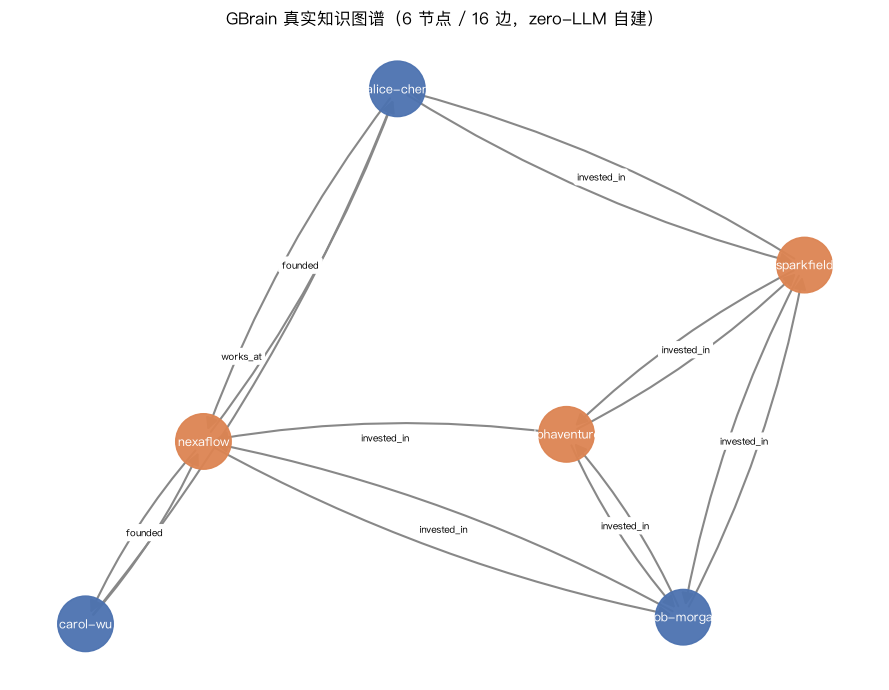

In [29]:
# ---- 用 plt 把内存里的 G 真正画出来（节点按类型着色、边标注关系类型） ----
# macOS 中文标题需要指定字体，否则 title 里的中文会变成方框
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Arial Unicode MS", "Heiti SC"]
plt.rcParams["axes.unicode_minus"] = False

# 固定 seed → 每次布局一致，便于和讲义截图对照（spring_layout 默认带随机性）
pos = nx.spring_layout(G, seed=42, k=1.2)

# 按节点类型分配颜色：person 蓝、company 橙
type_color = {"person": "#4C72B0", "company": "#DD8452"}
node_colors = [type_color[G.nodes[n]["node_type"]] for n in G.nodes]

plt.figure(figsize=(9, 7))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1600, alpha=0.95)
nx.draw_networkx_labels(G, pos, font_size=9, font_color="white")
# DiGraph → 带箭头，arrows=True 体现方向（A→B 与 B→A 含义不同）
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=18,
                        edge_color="#888888", width=1.5,
                        connectionstyle="arc3,rad=0.08")  # 微弧度，避免双向边重叠
# 边上标注关系类型（works_at / founded / invests_in 等），来自 edge_type 属性
edge_labels = {(u, v): d["edge_type"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7,
                            label_pos=0.5, rotate=False)

plt.title(f"GBrain 真实知识图谱（{G.number_of_nodes()} 节点 / {G.number_of_edges()} 边，zero-LLM 自建）")
plt.axis("off")
plt.tight_layout()
plt.show()

&emsp;&emsp;注意这段代码**不再硬编码任何边**——它用 `subprocess` 把你刚才 4.7 跑出的 `gbrain graph-query` 输出原样解析进来，所以画的就是你本机 brain 的真实结果。在本课固定语料 + GBrain `0.42.44.0` 下会打印 `真实边数: 16 | 分布: {'founded': 4, 'invested_in': 10, 'works_at': 2}`（**若你的边数/分布不同，以这里打印的为准**——那是你 brain 的实际状态，先回 4.7 确认 `extract links` 已跑过）。把这个 `DiGraph` 用 matplotlib 画出来——就是 4.4 节那张图，只不过现在每一条边都来自你自己的 gbrain 输出：节点形状区分实体类型（圆形=人、方形=公司），边的颜色区分关系类型（橙=founded、蓝=works_at、绿=invested_in）。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171726624.png" width=50%></div>

&emsp;&emsp;这张图最该被记住的一点，标题已经写明：**6 nodes · 16 edges · 3 types · zero LLM**。图里每一条线，都能追回到某一页 markdown 里某一行 `[[链接]]`——没有一条是大模型猜出来的。这正是 self-wiring 与"大模型抽实体建图"最直观的区别：图谱的每一笔都是人显式写下的，机器只做了忠实的解析。顺带看一眼边类型的分布。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171851625.png" width=50%></div>

&emsp;&emsp;在本课固定语料 + GBrain `0.42.44.0` 下，分布是 `invested_in: 10, founded: 4, works_at: 2`，合计 16（注意 advises 是 **0**）——这正是上一段画图代码里 `Counter` 打印出来的，你本机若不同就以你打印的为准。这张分布本身就藏着本节最该讲的诚实点——**zero-LLM 正则只看措辞的邻近关系、不真正理解语义，所以会判错**。在这个截图环境里能观察到三处真实的误判：① alice-chen 正文写的是"advisor to [[companies/sparkfield]]"（顾问），却被归成了 `founded`；② bob-morgan 正文写"works at [[companies/alphaventures]]"（任职），被归成了 `invested_in`；③ nexaflow 正文"led by [[people/carol-wu]]"（带领）也被归成 `founded`。这就是为什么我们语料里明明设计了"顾问"关系，最终 `advises` 却是 0 条。这恰好把 zero LLM 方案的取舍照得很清楚：**好处是确定性（同输入永远同图、每条边可溯源），代价是非语义完美（碰到措辞误导会判错）**。GraphRAG 用大模型做语义理解，这种情况大概率判对，但代价是调用成本和"两次抽取结果可能不同"的不确定性。两条路各有取舍。

&emsp;&emsp;**步骤二：删一个链接前缀，看对应的边消失（请按四步逐 cell 顺序跑，别整页 Run All）**

&emsp;&emsp;这个变体实验当场验证两件事：图谱是不是 markdown 的实时镜像，以及4.6 节那个"静默少边"坑是不是真的。下面把"改文件 → 写回 brain → 查边 → 恢复"串成可直接运行的 cell——但**请一个一个按顺序跑，不要整页 Run All 跳着执行**，因为每个 cell 都依赖前一个改完文件、写回 brain。

&emsp;&emsp;**第一步**：删掉 alice-chen 指向 sparkfield 的链接前缀（`[[companies/sparkfield]]` → 纯文字 `SparkField`），并留存原文供第四步恢复。

In [30]:
from pathlib import Path
ALICE = Path("gbrain-wikilink-data/people/alice-chen.md")
alice_original = ALICE.read_text(encoding="utf-8")     # 留存原文,第四步恢复用
ALICE.write_text(alice_original.replace("[[companies/sparkfield]]", "SparkField"), encoding="utf-8")
print("已删 alice-chen 里的 [[companies/sparkfield]] 链接前缀(改成纯文字 SparkField)")

已删 alice-chen 里的 [[companies/sparkfield]] 链接前缀(改成纯文字 SparkField)


&emsp;&emsp;**第二步**：把改过的页 `gbrain put` 写回 brain。**重点看返回的 `auto_links` 里 `"removed": 1`**——正是那条悬空的 `founded → sparkfield` 边被删掉了：

In [31]:
# gbrain put 写入时立即重新提取该页链接、对比新旧边集合,删悬空边、建新边
# 关键看 auto_links 的 "removed": 1(删掉的就是 founded->sparkfield 这条悬空边)
!cat gbrain-wikilink-data/people/alice-chen.md | gbrain put people/alice-chen

{
  "slug": "people/alice-chen",
  "status": "created_or_updated",
  "chunks": 1,
  "auto_links": {
    "created": 2,
    "removed": 1,
    "errors": 0,
    "unresolved": []
  },
  "auto_timeline": {
    "created": 0
  },
  "writer_lint": {
    "skipped": "flag_disabled"
  },
  "facts_backstop": {
    "skipped": "kind:person"
  },
  "write_through": {
    "written": false,
    "skipped": "no_repo_configured"
  }
}


&emsp;&emsp;**第三步**：查 alice-chen 出边，确认 `founded → companies/sparkfield` 已经消失：

In [32]:
!gbrain graph-query people/alice-chen --direction out --depth 1

[depth 0] people/alice-chen
  --founded-> companies/nexaflow (depth 1)
  --works_at-> companies/nexaflow (depth 1)


&emsp;&emsp;**第四步**：恢复原文并写回，别给后续溯源留污染：

In [33]:
ALICE.write_text(alice_original, encoding="utf-8")     # 恢复成删之前的完整内容
print("已恢复 alice-chen 原文")
!cat gbrain-wikilink-data/people/alice-chen.md | gbrain put people/alice-chen

已恢复 alice-chen 原文
{
  "slug": "people/alice-chen",
  "status": "created_or_updated",
  "chunks": 1,
  "auto_links": {
    "created": 1,
    "removed": 0,
    "errors": 0,
    "unresolved": []
  },
  "auto_timeline": {
    "created": 0
  },
  "writer_lint": {
    "skipped": "flag_disabled"
  },
  "facts_backstop": {
    "skipped": "kind:person"
  },
  "write_through": {
    "written": false,
    "skipped": "no_repo_configured"
  }
}


&emsp;&emsp;最该盯住的是第二步 `gbrain put` 返回的 `auto_links` 里 `"removed": 1`——GBrain 写入时立即重新提取该页链接，发现 `[[companies/sparkfield]]` 不见了，于是把对应的那条 `founded → sparkfield` 悬空边删掉了。第三步查出边，这条边确实消失了。这就是**图谱是 markdown 镜像**最直接的证据：链接在边就在，链接删了（或漏了前缀）边就走。

&emsp;&emsp;**但要诚实交代一个 `gbrain put` 的真实行为**：它会按当前规则**重新解析整页**，所以返回常常是 `{"created": 2, "removed": 1}` 而不是只 `removed: 1`——那个 `created` 里，除了重建 alice 仍有的 `founded → nexaflow`，还会**多出一条 `works_at → nexaflow`**：它来自 alice 页 frontmatter 的 `company: NexaFlow`（4.6 节讲的 frontmatter 映射规则）。而 4.7 节我们用 `extract links` 批量建边时只取了正文 wikilink 来源、没建这条。也就是说，**`put`（单页热写入）和 `extract links`（批量提取）的建边来源不完全一样**，put 会把 frontmatter 边也补进来。所以看这个实验请**聚焦 `removed: 1` 和"sparkfield 边从出边列表消失"这两点**，不要纠结全图总边数有没有精确变化——put 的 frontmatter 副作用会让总数对不上 4.7 的 16。若想把全图干净复位回 16 条，最稳的是回 4.7 重跑一次 `gbrain import` + `gbrain extract links --source db`（而不是靠 put 恢复）。这也正面验证了"静默少边"那个坑的真实性。

&emsp;&emsp;但请注意一个和全课一致的边界：这个"镜像"是在你**执行 `gbrain put` / `extract links` 的那一刻**重新对齐的，**不是自动盯着磁盘**。如果你在编辑器里改了 markdown 却没有 put、也没重跑 extract links，brain 里的页面和边仍是上一次同步的旧状态——这和"改了 `raw/` 不重新 ingest、wiki 不变"、"改了源文档不重建向量索引、检索不变"是同一回事：**源 → 中间产物之间永远有一道需要你主动触发的同步**。GBrain 的优势不在"自动读到任意磁盘变化"，而在把页面、边和 provenance（来源）管理得更可检视——这也是下一节 `backlinks` 溯源要展示的。

> **【动手想一想】**：把 `[[companies/nexaflow]]` 改成 `[[nexaflow]]`（去掉目录前缀），这条边还在吗？——在默认配置下，去掉前缀后那条带类型的 `founded` 边会**静默消失且不报错**（put 后在 `graph-query` 里该 slug 的这条出边就不见了；至于全图总数，受上面说的 put frontmatter 副作用影响，以实际 `graph-query` 为准）。原因是负责 typed edge 的 `WIKILINK_RE` 只认带前缀的格式；GBrain 虽另有一条不挑前缀的泛化匹配，但它默认关闭、且只产无类型边（即4.6 节补充说明里的那个 `global_basename` 开关）。你可以去 `gbrain graph-query` 里验证。这就是"默认配置下必带目录前缀"为什么是建出 typed edge 的关键。

&emsp;&emsp;**步骤三：把一条边溯源到它来自哪一行 markdown**

&emsp;&emsp;zero LLM 还带来一个大模型方案很难做到的性质：**每一条边都能精确追溯到它来自哪一行 markdown**。选 `alice-chen --founded--> nexaflow` 这条边，用 `grep` 在源文件里定位，再用 `gbrain backlinks` 看 GBrain 自己记录的上下文。

&emsp;&emsp;**第一条·在源文件里定位**：找 `founded` 和那个 wikilink 各出现在第几行（`-n` 在每个匹配前打印行号；`"A\|B"` 里 `\|` 是 grep 正则的"或"——一次同时找 `founded` 或 `[[companies/nexaflow]]`）。

In [34]:
!grep -n "founded\|\[\[companies/nexaflow\]\]" gbrain-wikilink-data/people/alice-chen.md

5:founded: NexaFlow
8:Alice Chen is the founder of [[companies/nexaflow]], which she co-founded in 2021.


&emsp;&emsp;**第二条·看 GBrain 记录的上下文**：`gbrain backlinks` 显示 GBrain 为这条边存下的上下文窗口与来源标记。

In [35]:
!gbrain backlinks companies/nexaflow

[
  {
    "from_slug": "companies/alphaventures",
    "to_slug": "companies/nexaflow",
    "link_type": "invested_in",
    "context": "aVentures [[people/bob-morgan]] is a partner at AlphaVentures, leading investments. AlphaVentures' portfolio includes [[companies/nexaflow]] and [[companies/sparkfield]].",
    "link_source": "markdown",
    "origin_slug": null,
    "origin_field": null
  },
  {
    "from_slug": "people/alice-chen",
    "to_slug": "companies/nexaflow",
    "link_type": "founded",
    "context": "# Alice Chen Alice Chen is the founder of [[companies/nexaflow]], which she co-founded in 2021. Alice Chen is an advisor to [[companies/sparkfield]], serving as a t",
    "link_source": "markdown",
    "origin_slug": null,
    "origin_field": null
  },
  {
    "from_slug": "people/bob-morgan",
    "to_slug": "companies/nexaflow",
    "link_type": "invested_in",
    "context": "# Bob Morgan Bob Morgan works at [[companies/alphaventures]] as a general partner. Bob Morgan invested 

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171854253.png" width=50%></div>

&emsp;&emsp;这张截图把一条边的完整身世摊开了：`grep -n` 定位到源文件里那一行——`Alice Chen is the founder of [[companies/nexaflow]]`，"founder of"这个措辞加紧跟的 wikilink，就是这条 `founded` 边的全部依据。`gbrain backlinks` 返回的 JSON 里，`context` 字段存着一段源文本窗口，`link_type` 字段标着 `founded`，`link_source` 字段标 `markdown`（表明这条边来自正文里的 wikilink，而非 frontmatter 字段）。至于"为什么偏偏是 `founded`"——那是4.6 节讲的正则规则在起作用（"founder of"这个动词触发了 founded 类型推断）；GBrain 本身不会在输出里附带这条推断理由，需要你对照规则自己读出来。截图底部那条追溯链把整条路径串成一句话：源文件里那一行 `[[companies/nexaflow]]` → 正则命中（zero LLM）→ 图里的一条 founded 边 → 可用 backlinks 查回。**每条边都对应一条明确的正则规则和一行明确的源文本**——谁、在哪、凭哪条规则建了这条边，全都可查。这种可审计性，是 zero LLM 方案的直接红利。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171900138.png" width=58%></div>

### 4.9 一个必须讲清的区分：Obsidian 看不到 typed edge 类型

&emsp;&emsp;这一节解决一个极容易让人误会的点。3.11 节我们用 Obsidian 看过 wiki 的互链网络，你可能会想——那第四章这些带类型的边，是不是也能在 Obsidian 里看到？**不能。这一点必须讲清楚，否则你会误以为 Obsidian 能看到完整图谱。**

&emsp;&emsp;关键区别是：**Obsidian Graph View 只显示"页之间有没有连接"，它看不到 GBrain typed edge 的类型标签**（founded / invested 那种有向、带类型的边）。Obsidian 画出来的是无类型、无方向的连线网络——它能告诉你"A 和 B 之间有关系"，但告诉不了你"A `founded` B"还是"A `invested_in` B"。而我们4.8 节画的那张带颜色、带箭头、带类型的有向图谱，是用 networkx 画的，不是 Obsidian。

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>看图工具的能力边界：Obsidian vs networkx</font></p>

<div class="center">

| 维度 | Obsidian Graph View | networkx（Python 绘图） |
|------|--------------------|------------------------|
| 显示连接 | 是（页间有无连接） | 是 |
| 显示方向 | 否（无向连线） | 是（有向箭头） |
| 显示类型标签 | **否**（看不到 founded/invested） | 是（不同颜色区分类型） |
| 交互 | 实时、可拖拽、零代码 | 静态图、需写代码 |
| 适用场景 | 快速一览"有没有关系" | 看清"是什么关系" |

</div>

&emsp;&emsp;所以两者的分工很清楚：**第三章看 wiki 互链网络，用 Obsidian 正好**（零代码、可拖拽、看个连接结构）；**第四章看带类型的彩色有向图谱，要用 networkx**（能把 founded / invested 的类型和方向画出来）。Obsidian 在第四章这里只能当一个"有没有关系"的快速一览补充，看不到 typed edge 的全貌。把这点记清楚，你就不会误以为装了 Obsidian 就能看到完整的关系类型图谱。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171923158.png" width=58%></div>

### 4.10 GBrain vs GraphRAG：区别轴是构图方式

&emsp;&emsp;第四章收尾，我们把2.7 节立的那条红线正面兑现——GBrain 和 GraphRAG 的区别轴是"构图方式"，不是"贵不贵"。要看清这个分野，最干净的办法是拿一份**纯散文、完全没有 `[[wikilinks]]`** 的文本，看 GBrain 在它上面会发生什么。GraphRAG 官方教程常用狄更斯的《A Christmas Carol》，我们下载它统计一下。

&emsp;&emsp;**第一条·下载语料**：取狄更斯《A Christmas Carol》（纯散文，无任何 `[[wikilinks]]`）到 `/tmp`（`-s` 静默下载，无进度输出）。

In [36]:
!curl -s https://www.gutenberg.org/cache/epub/24022/pg24022.txt -o /tmp/christmas-carol.txt

&emsp;&emsp;**第二条·数单词量**：`wc -w` 看这篇散文一共多少个单词。

In [37]:
!wc -w /tmp/christmas-carol.txt

   32462 /tmp/christmas-carol.txt


&emsp;&emsp;**第三条·数主角出现行数**：`grep -c` 数有多少行提到这几个主角（`-c` 只输出匹配的行数，`\|` 同样表示"或"）。

In [38]:
!grep -c "Scrooge\|Marley\|Ghost\|Bob Cratchit" /tmp/christmas-carol.txt

484


<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171936555.png" width=50%></div>

&emsp;&emsp;数据说话：《A Christmas Carol》有 32462 词、484 次实体提及，但**一个 `[[wikilink]]` 都没有**。所以如果把它喂给 GBrain，结果是 **0 条 typed edges**——这不是 bug，而是设计。GBrain 根本不是用来从非结构化散文里抽关系的工具，它只解析已经显式写好的结构——正文里的 `[[链接]]`、frontmatter 里的关系字段、以及 `[文字](目录/slug)` 这类带路径的 markdown 链接；而纯散文这三样一样都没有。截图里把三个场景说透了：GBrain 跑散文（0 链接 → 0 边，设计边界）、GraphRAG 跑散文（大模型读文本抽实体推关系建三元组，需大模型 API，默认生成 Parquet 图结构产物并写入向量存储，结果非确定）、GBrain 跑 wiki markdown（zero LLM 确定建边、可溯源、只需本地 PGLite）。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617171939875.png" width=62%></div>

下面这张表是本章的结论。

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>GBrain vs GraphRAG：四条区别轴（反稻草人）</font></p>

<div class="center">

| 区别轴 | GBrain（self-wiring） | GraphRAG |
|--------|---------------------|----------|
| 构图方式 | 解析 markdown 里显式的 `[[links]]` | 大模型从纯文本抽取实体与关系 |
| 确定性 | 同输入永远同图 | 大模型随机性，结果可能不同 |
| 可审计性 | 每条边溯源到 markdown 某一行 | 较难追溯到具体出处 |
| 基础设施 | 本地 PGLite，无需图数据库 | 需要大模型 API；官方默认输出 Parquet 图结构产物，embeddings 写入配置的 vector store |

</div>

&emsp;&emsp;所以"GBrain 和 GraphRAG 的根本区别是什么"这个问题的答案是：**区别轴首先是构图方式——一个解析显式链接、一个大模型抽实体——而不是贵不贵**。成本只是构图方式不同带来的副产物，不是分野本身。选哪个，取决于你的输入是什么：如果知识本来就以互链 markdown 的形式存在（笔记库、wiki、文档），GBrain 的确定性和可审计性很合身；如果要从一堆没有结构的散文（小说、新闻、报告）里挖关系，那是 GraphRAG 的主场。

> **【动手想一想】**：如果要给一份没有任何 `[[链接]]`、纯散文的 100 篇研报建图谱，GBrain 的 self-wiring 还成立吗？该换谁？——不成立。self-wiring 的前提是关系已被人用 `[[链接]]` 显式声明，纯散文里没有链接，GBrain 会建出 0 条边。这种"从无结构文本挖关系"的需求，正是 GraphRAG 的主场。这个判断，正是第五章选型决策树要交给你的能力。

&emsp;&emsp;第四章到这里收束。你已经握住了 GBrain self-wiring 的完整证明：本课固定语料下解析出的那一批带类型有向边（截图环境是 16 条），来自人显式写好的 `[[链接]]` ＋ 正文措辞，零大模型，每条都能溯源回某一行 markdown，删掉链接对应的边就消失——图谱是 markdown 的实时镜像，这一点你也亲手验证过。但能力越强越要保持清醒——第五章，我们用一组实测数据，给这个范式做一次诚实的体检。

---

## <center>第五章：诚实边界——三元选型与取舍</center>

&emsp;&emsp;前三章把编译式 RAG 的原理跑通了、也看了 GBrain 的自动建图。顺着这个印象很容易冒出一个直觉："它又可读、又能跨源合成、还能零大模型建图，是不是全面更优、无脑选它就行？"这一章用一组一手实测数据检验这个直觉——它直接关系到技术选型：会判断"我的场景到底该不该用它"，和会搭它同样重要。我们顺带把两条最容易被误解的边界并排记住：第一章已经说清编译式**不会自动同步**（改了原料得自己重新编译）；这一章再校正第二条更反直觉的误解——它**也不是省 token 方案**。下面先顺着直觉选编译式，再用数据校正，最后给一棵能落地的选型决策树。

### 5.1 用约 20 倍 token 检验"省成本"的直觉

&emsp;&emsp;先把直觉摆出来：编译式 RAG 既然把知识预先编译好了，查询时只读几个提炼好的产物页，那它的查询成本是不是比每次重新检索的传统 RAG 更省？这个推理听起来很顺。

> **【先想一下】**：在学这门课之前，如果有人问你"编译式 RAG 把知识预编译好了，查询是不是更省成本"，你的第一反应大概率是"应该更省吧"。记住这个最自然的直觉——这一节我们就是要用一手数据，把它掰过来。

&emsp;&emsp;记住这个直觉了吗？那来看真实数据——这个"听起来很顺"的推理，其实**错了，而且错得很彻底**。在同一批知识、同一组查询的端到端对照实验里，编译式 wiki 一次查询要吞掉的 token **约是向量 RAG 的 20 倍**：向量 RAG 一次查询约 8 万 token，编译式 wiki 却要约 165 万——**整整高出一个数量级**。"省成本"这个直觉被彻底证伪了。

> **【关于"约 20 倍"这个数】**：这里的"约 20 倍"是本课实验室一次端到端实测跑出来的**量级**，不是一个能精确复现的常数——LLM 查询本身带随机性，换个问题、换次运行，具体 token 数和倍数都会浮动。所以请记住的是"编译式查询 token 比向量 RAG 高一个数量级（约 20 倍上下）"这个**方向**，而不是某个精确到个位的数字；真要拿它写选型报告，宁可说"约一个数量级"也别钉死成某个精确倍数。独立研究者一篇预注册对照实验（arxiv 2605.18490，2026-05）方向与此一致（编译式查询 token 远多于向量 RAG），其摘要未给具体数字，所以这里只引方向、不引数值。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617172015437.png" width=58%></div>

&emsp;&emsp;**为什么会这样？** 关键在于"查询时到底读了多少东西"。编译式查询为了做跨源合成、保证回答质量，往往需要把相关的多个 wiki 编译页（有时是相当大一块 wiki）读进上下文；而向量 RAG 只捞几个最相关的小片段。所以"摊薄使查询更便宜"这个机制，在实测的每查询成本下根本不可能成立——除非整个 wiki 常驻上下文，否则编译式只是把"重读源文件"换成了"重读 wiki"，是成本搬移，不是成本消除。

&emsp;&emsp;那编译式 RAG 真正的优势是什么？3.9 节我们已经从"重复劳动"这个角度定性看过一次——这一次是带着这个"约 20 倍"的量级重新算这笔账。它的真实价值在**跨源合成质量**和**人类可读性**：把多篇资料里互相矛盾的说法在编译期对齐好、沉淀成一份人能直接读的 wiki。账要这样算——它省掉的是"查询期重复消化原料的劳动"，但为此**多付出约一个数量级的查询 token**。所以这不是"省成本"，而是一笔明码标价的交换：用高出约 20 倍的查询算力，换来跨源合成质量与可读性。代价没有消失，只是被你看清了价签。

> **【踩坑预警】**：千万不要把编译式 RAG 当成"省成本方案"卖给团队或写进技术选型报告。后果是上线后查询成本远超预期（高出约一个数量级），背锅的是你；正确的定位是"用查询期算力和编译期运维，换跨源合成质量与可读性"；判断自己有没有误解的方法——如果你选它的理由里有"省 token / 省钱 / 查询更快"，那就是踩进了这个直觉陷阱，得重新评估。

### 5.2 三元选型决策树：什么场景用哪个

&emsp;&emsp;看清这一点之后，正确的做法不是"那就别用编译式了"，而是建立一套**按场景选型**的判断力。编译式、传统向量 RAG、GraphRAG 各有自己的主场，没有谁全面更优。这一节给你一棵能落地的三元决策树。先看决策的核心条件。

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>三元选型：四种方案的适用条件</font></p>

<div class="center">

| 方案 | 适用条件 | 核心优势 | 主要代价 |
|------|---------|---------|---------|
| 编译式 wiki | 知识稳定（更新慢）+ 需跨源合成 + 规模 < ~100 篇 | 跨源合成质量、人类可读、可审计 | raw 变更后需重新 ingest、查询 token 约 20×、有规模天花板 |
| 传统向量 RAG | 海量（100K+）/ 高频查询 / 严格 SLA / 单跳事实检索 | 召回宽、响应快（毫秒级）、对新数据响应快 | 跨源合成多在查询期、索引不可读、源变更后需重建/增量更新 |
| GraphRAG | 需要从**非结构化散文**里做多跳关系推理 | 语义理解强、能从纯文本抽实体关系 | 大模型成本、结果不确定、索引产物与存储配置更复杂 |
| 混合 | 核心知识稳定 + 易变数据海量 | 稳定走编译保权威 + 易变走 RAG 保灵活 | 架构复杂度高 |

</div>

&emsp;&emsp;把这张表串成一个可执行的判断流程，就是下面这棵决策树——从"我有一批知识要让 AI 用好"出发，按几条判断条件一步步分流到四种方案。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617172024211.png" width=50%></div>

&emsp;&emsp;这棵树最关键的两个判断点：第一个是**知识稳不稳定**——老手判断要不要上编译式，不看它热不热门、star 多少，只看一条硬指标：知识是不是更新得足够慢（每周甚至更慢）。频繁更新的知识用编译式，编译成本会被频繁的重编译吃掉。第二个是**规模天花板**——编译式有一个大约 100 篇 / 400K words 的实践上限，超过这个量级，编译开销和 wiki 的可维护性都会成问题，该切传统 RAG。把这两条记牢，你就有了选型的核心依据。

> **【动手想一想】**：你的知识库从 80 篇涨到 10 万篇、且每小时更新，选型该从编译式切到什么？切的临界点在哪？——答案是切到传统向量 RAG。临界点有两条：规模越过约 100 篇 / 400K words 的天花板、更新频率高到"每次更新都要重编译"得不偿失。这两条任意一条越线，编译式的代价就开始压过它的合成质量收益。

&emsp;&emsp;关于 GraphRAG 那一支，请务必带着4.10 节的红线来看：选不选 GraphRAG 的判断轴是**你的输入是不是无链接的纯散文、需不需要从中挖多跳关系**，不是"它贵不贵"。如果你的知识本来就以互链 markdown 存在，GBrain 的 self-wiring 又确定又可审计；如果你要从一堆纯散文里抽关系，那才是 GraphRAG 的主场。**区别轴是构图方式，不是成本**——这条红线我们从第二章讲到第五章，因为它是最容易被简化成稻草人的地方。

### 5.3 速查表：几个边界条件

&emsp;&emsp;关于编译式 RAG 的边界，还有几个细节值得知道，但它们不影响你今天做选型判断，所以我们只一句话带过、列成速查表，你课后需要时再细查。

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>编译式 RAG 边界速查（课后自查）</font></p>

<div class="center">

| 维度 | 一句话结论 |
|------|----------|
| 关系推理能力 | 是弱项——无一等的多跳 / 时序检索；端到端混合实验里 both 型查询命中率仅约 33%（详见下方说明） |
| 规模天花板 | 约 100 篇 / 400K words，超过则可维护性下降（社区实践经验，无发表基准） |
| 查询延迟 | 编译式约 3-8 秒，明显慢于向量 RAG 的毫秒级响应（约 200-500 毫秒）（实验室一手观测，无独立发表基准） |
| 知识库（KB）投毒风险 | wiki 是 LLM 编译产物，若原料被污染，错误会被固化进 wiki 且不易检测 |
| 查询命令坑 | 若用 `gbrain query`（语义检索）记得加 `--no-expand`，否则 PGLite 后端默认开 expansion 会卡到约 100% CPU 不出结果（GBrain Issue #1368） |

</div>

> **【关于那个 33% 的诚实说明】**：速查表里"both 型查询命中率约 33%"这个数字，来自本课实验室 Stage 3 的**端到端混合检索实验**（9 条查询、三形态对照中的一个切片）。请注意两点：第一，这是**端到端命中率，不是学术 benchmark**——它衡量的是"在这套特定混合架构、这 9 条查询上跑出来的命中表现"，不能当成"编译式关系推理能力的通用打分"。第二，关于编译式/GBrain 的检索基准，GBrain 官方在一份约 240 页的**自建语料**（BrainBench）上报告了 P@5 约 49.1%、R@5 约 97.9%（见项目 README，完整评分卡在 gbrain-evals 仓库）——这两个数字出自同一份自建语料，eval 代码开源可复现，但语料是厂商自建、且是官方自测而非独立第三方评测，所以要带"自建语料 + 官方自报"双重 caveat。GBrain 也支持在公开数据集 LongMemEval 上跑 eval（`gbrain eval longmemeval`），但本课没有它在该公开集上的复现数字，故不引用具体值。一句话：**关系推理是编译式的弱项，但请用准确的措辞描述它，别把端到端切片夸大成 benchmark**。

&emsp;&emsp;速查表最后一行"KB 投毒风险"值得我们多停一会儿，因为它和这个范式的根基直接相关。我们用一个通用场景把它讲实：假设你的某篇原料里有一句过时或干脆错误的断言（比如某个参数的旧默认值），它会怎么传播？在传统向量 RAG 里，这个错误通常停留在**源 chunk / 索引命中的证据层**——只在查询命中那个片段时才进入答案；它当然也会一直存在（直到源文档或索引被修正），但它**不会被进一步加工**：不会被 LLM 综合进多个页面、和别的结论对齐互链，也就不会升级成一条新的"中心结论"。但在编译式里，路径完全不同：LLM 在编译期会把这句被污染的原料**写进 wiki 产物**，还会拿它去和其他页面做对齐、互链、综合。于是从这一刻起，这条错误就被固化进了知识层，之后**所有**查询都在这份被污染的产物上推理——而且越查越像"既定事实"。

&emsp;&emsp;更麻烦的是边界的消失。在编译产物里，原始原料的事实和 LLM 的解释、综合被揉成了一体，你很难再分清"这句结论到底是原料里写的，还是 LLM 编译时推断出来的"。原始文档与 LLM 解释之间那道清晰的边界，在编译这一步永久地消失了。这意味着错误不仅被固化，还变得难检测——它不会触发任何报错，每条 wiki 页单独看都自洽，问题只在"它和源头对不对得上"这个层面，而这个层面恰恰被编译抹平了。

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260617172032713.png" width=58%></div>

> **【常见误区】**：很多人以为"编译式让知识沉淀下来"全是好事。它的另一面是：**沉淀的不只是正确知识，也包括被污染的原料**。后果是一旦某篇原料带错，错误会被写进 wiki 产物、和其他页对齐，之后每次查询都在错误产物上推理，且因为原料与 LLM 解释的边界已消失，错误既被固化又难检测；正确做法是把好编译的"入口"——`raw/` 原料进库前做事实核验（这正是 `raw/` 只读不可变这条纪律的另一层意义：它逼你在放进去之前就对原料负责），并定期用 Lint 巡检 wiki 与源头的一致性；判断自己是否已暴露在这个风险下的方法——抽查 wiki 里几条关键结论，回去 `raw/` 找它的源行，看 LLM 有没有在编译时悄悄改写或过度推断。

&emsp;&emsp;把第五章收束成一句话：**编译式 RAG 有明确的适用区间**——知识稳定、需要跨源合成、规模可控的场景。它不是对传统 RAG 的全面替代；它强在合成质量与可读性，不强在成本和速度。带着这套判断依据和这棵决策树，我们进入最后一章——把今天学到的一切，迁移到你自己的知识上。

---

## <center>第六章：迁移——从别人的 wiki 到自己的</center>

&emsp;&emsp;走到这里，我们已经把编译式 RAG 从"机器索引 vs 可读 wiki"的中间产物差异、原理骨架、最小闭环、自动建图一路讲到了诚实边界。但所有这些，到目前为止用的都是"别人的资料"——三篇精心设计的张力原料、6 页虚构的公司人物语料。这最后一章，我们要把它变成"你自己的"：用今天学到的三层 + 三操作，给你真实的笔记设计一个第二大脑结构，并回看一遍你今天走过的完整效果链。这是本课的收口——不留作业悬念、不预告后续，只把今天的能力扎扎实实地交到你手上。

### 6.1 迁移任务：给你自己的知识设计一个第二大脑

&emsp;&emsp;现在轮到你动手了。挑一批你手上真实的、有点价值的知识——可以是你的会议纪要、项目笔记、或者一份联系人/合作方的关系清单。用今天的方法，给它设计一个编译式的第二大脑结构。具体怎么落地，取决于你的知识形态，有两种变体可选。

&emsp;&emsp;**变体 A：选 Karpathy 最小原型（推荐先从这个开始）**

&emsp;&emsp;如果你的知识主要是"概念 / 资料 / 笔记"这类需要跨源合成的内容，走第三章那套最小原型最合适。动手清单是：① 建 `raw/` + `wiki/` 三层目录、git init；② 写一份 `CLAUDE.md` schema（页面命名、链接语法、三操作边界——可以直接改用3.4 节那份骨架）；③ 放进你自己的原料，**记得刻意挑有跨源张力的几篇**（3.5 节那条隐藏前提，是你的 wiki 能不能体现编译式价值的关键）；④ 启动 agent 跑 ingest（别忘了 `env -u ANTHROPIC_API_KEY`）；⑤ 用 `find` 看 ingest 前后目录对照，确认 `raw/` 没变、`wiki/` 长出来了；⑥ 用 Obsidian 打开 `wiki/` 看你自己的知识网络——打开后你会第一次看到**属于你自己知识**的那张网络在眼前长出来，这正是第三、四章那张演示图在你自己资料上的复现。

&emsp;&emsp;**变体 B：选 GBrain 生产流（你的知识有明确的关系结构时）**

&emsp;&emsp;如果你的知识本身就有清晰的"实体 + 关系"结构（比如团队成员与项目的关系、模块之间的依赖、合作方的投资/顾问关系），那第四章的 GBrain 自动建图更对路。动手清单是：① 每个实体写一页 markdown，frontmatter 标 `type:`；② 正文里用 `[[目录/slug]]` 显式写出关系，**目录前缀绝不能漏**（4.6 节的静默少边坑）、目录名要在白名单里；③ `gbrain import <你的目录> --no-embed`；④ 补跑 `gbrain extract links --source db`（`--no-embed` 后必须这步）；⑤ 用 `gbrain graph-query` 检视 typed edges，用 networkx 画图，用 `gbrain backlinks` 把每条边溯源回源行。

> **【迁移任务的验收标准】**：变体 A 跑成的标志——你的 `wiki/` 从空目录长出了 5 个以上带 frontmatter 的互链页，`raw/` 全程不变，并且你能在 Obsidian 里指着某条连线说出它对应哪两页。变体 B 跑成的标志——你能在 `gbrain graph-query` 里看到带类型的有向边，并能用 `gbrain backlinks` 把任意一条边追回它来自哪一行 markdown。能做到这些，就说明你不只是"会照着敲命令"，而是真正理解了"图谱 = markdown 里链接的实时镜像、由规则解析而非大模型理解"这件事。

### 6.2 回看全流程 + 能力自测

&emsp;&emsp;在结束之前，我们把今天走过的完整效果链回放一遍——从空目录到知识图谱，这一路你亲手跑过的每一步，都对应着一个具体能力的获得。

&emsp;&emsp;这一路你做成了五件实事：看清传统 RAG 与编译式 RAG 的中间产物差异——机器索引 vs 可读 wiki（第一章），用"解释 vs 编译"的心智地图理解为什么 wiki 能把跨源合成沉淀下来（第二章），亲手跑通 `raw/` 不动、`wiki/` 从空到有的最小编译闭环（第三章），看到 16 条带类型的边零大模型自动建出、并能逐条溯源（第四章），最后用约 20 倍 token 的实测把"省成本"直觉校正成一棵选型决策树（第五章）。看清差异 → 懂原理 → 跑闭环 → 会建图 → 会取舍，这条路你已经走完。

&emsp;&emsp;最后，用三句话给自己做个自测——如果下面这三个问题你都能在 30 秒内答出来，今天的内容你就真正带走了。

1. **编译执行和解释执行的根本区别是什么？** 解释执行（传统 RAG）把跨源合成压在每次查询里临时做，中间产物是难审计的机器索引；编译执行（编译式 RAG）把跨源合成前置到编译期、沉淀成一份可读 wiki，查询时复用这份产物。要补一句：二者**都有中间产物、也都要在源材料变化后更新它**——区别在中间产物是机器索引还是可读 wiki。

2. **GBrain 和 GraphRAG 的区别轴是什么——是不是"贵不贵"？** 不是贵不贵，是**构图方式**：GBrain 解析人写好的显式 `[[链接]]`（零大模型、确定、可审计），GraphRAG 用大模型从纯散文抽实体关系（语义强、但有成本和不确定性）。成本只是构图方式不同的副产物。

3. **我的场景该用编译式还是传统 RAG，判断标准是什么？** 看两条硬指标——知识是否稳定（更新慢）、规模是否在约 100 篇 / 400K words 以内。两条都满足且需要跨源合成，才用编译式；海量 / 高频 / 严格 SLA / 单跳事实，留给传统 RAG。

> 📌 **【一套判断依据，带去你自己的场景】**：今天我们一起搭起的，不只是一个 wiki，更是一套判断"知识该怎么存、该用哪种 RAG"的依据。回到你自己的工作里——下次再有人说"上个 RAG 吧"或者"这个编译式 RAG 很热门，咱们也搞一个"，你已经能从"知识稳不稳定、规模多大、要不要跨源合成、输入是不是纯散文"这几个维度，给出一个有依据的判断，而不是被热度牵着走。这套判断依据，比任何一个具体工具都更长效。

&emsp;&emsp;编译式 RAG 不是万能方案，而是一种有明确边界的取舍。把这个判断和今天这套选型依据一起带走，你就能在自己的真实场景里，做出比"跟风"更可靠的技术决策。这，正是本课想交给你的东西。